# Prescription Refill Risk — Exploratory Data Analysis
**Pharmacy2U | DE-SynPUF Part D | Data & AI Hackathon**

Explores `full_df_with_msr.parquet` produced by the data cleaning notebook. Informs feature selection and modelling decisions.

| # | Section | Focus |
|---|---------|-------|
| 1 | Load Data & Build MISSES Label | Attach refill outcome (`In time` / `Late` / `NA`) |
| 2 | Dataset Overview & Data Quality | Shape, missingness, descriptive stats |
| 3 | Temporal Patterns | Monthly volume, day-of-week, days-supply distribution |
| 4 | Patient Demographics | Age, sex, race, mortality, ESRD |
| 5 | Drug & Dispensing Behaviour | Top ingredients, quantity, claims per patient |
| 6 | Comorbidity Landscape | Condition prevalence, co-occurrence, system groupings |
| 7 | Financial Signals | Cost distributions, OOP ratio, high-barrier flag |
| 8 | Engineered Flags | Binary flag prevalence, frailty breakdown |
| 9 | Late Refiller Analysis | Gap distribution, late rate by drug / condition / time |
| 10 | Correlation & Multivariate | Feature correlation, pairplot |
| 11 | EDA Summary | Key findings printed for reference |


In [2]:
from google.colab import drive
drive.mount('/content/drive')
link = '/content/drive/MyDrive/pharma2u/datasets/full_df_with_msr.parquet'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
PALETTE = sns.color_palette('muted')
GRACE_DAYS = 14

---
## 1. Load Data & Build MISSES Label

Loads `full_df_with_msr.parquet` from Google Drive and attaches a `MISSES` label to each fill:

| Value | Meaning |
|-------|---------|
| `In time` | Next fill arrived within the grace window |
| `Late` | Next fill arrived more than `GRACE_DAYS` after run-out |
| `NA` | Last fill for this patient-ingredient — no subsequent fill to evaluate |

> **File path:** update `link` in the first code cell to match your Google Drive folder (default: `MyDrive/pharma2u/datasets/full_df_with_msr.parquet`).


In [5]:
# ── Load parquet ──────────────────────────────────────────────────────────────
df = pd.read_parquet(link)

if df.index.name == 'DESYNPUF_ID':
    df = df.reset_index()

for col in ['SRVC_DT', 'BENE_BIRTH_DT', 'BENE_DEATH_DT']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.sort_values(['DESYNPUF_ID', 'INGREDIENT', 'SRVC_DT']).reset_index(drop=True)

print(f'Loaded  : {len(df):,} rows')
print(f'Patients: {df["DESYNPUF_ID"].nunique():,}')
print(f'Columns : {df.shape[1]}')
print(f'Dates   : {df["SRVC_DT"].min().date()} → {df["SRVC_DT"].max().date()}')

Loaded  : 5,373,237 rows
Patients: 92,118
Columns : 56
Dates   : 2008-01-01 → 2010-12-31


In [6]:
# ── Build MISSES label grouped by DESYNPUF_ID + INGREDIENT ───────────────────
# (grouping by NDC gives only ~3k pairs; INGREDIENT reconstructs the real sequence)

df['RUN_OUT_DATE'] = df['SRVC_DT'] + pd.to_timedelta(df['DAYS_SUPLY_NUM'], unit='d')

grp = df.groupby(['DESYNPUF_ID', 'INGREDIENT'], observed=True)
df['next_fill_dt'] = grp['SRVC_DT'].shift(-1)
df['gap_days']     = (df['next_fill_dt'] - df['RUN_OUT_DATE']).dt.days

df['MISSES'] = 'NA'   # censored (last fill per patient-ingredient)
df.loc[df['gap_days'].notna() & (df['gap_days'] <= GRACE_DAYS), 'MISSES'] = 'In time'
df.loc[df['gap_days'].notna() & (df['gap_days'] >  GRACE_DAYS), 'MISSES'] = 'Late'

# ── Binary flag for modelling ─────────────────────────────────────────────────
df['is_late'] = (df['MISSES'] == 'Late').astype('Int8')
df.loc[df['MISSES'] == 'NA', 'is_late'] = pd.NA

labelled = df[df['MISSES'] != 'NA'].copy()
late_rate = (labelled['MISSES'] == 'Late').mean() * 100

print(f'MISSES distribution:')
print(df['MISSES'].value_counts(dropna=False).to_string())
print(f'\nLabelled fills : {len(labelled):,}  ({len(labelled)/len(df)*100:.1f}% of total)')
print(f'Late rate      : {late_rate:.1f}%  (grace = {GRACE_DAYS} days)')

MISSES distribution:
MISSES
In time    3541244
Late       1254580
NA          577413

Labelled fills : 4,795,824  (89.3% of total)
Late rate      : 26.2%  (grace = 14 days)


---
## 2. Dataset Overview & Data Quality

High-level audit of the loaded dataset:

- Row / patient / ingredient counts
- Date range and class balance (`MISSES` distribution)
- Missingness report — any column with > 0% nulls
- Descriptive statistics for all numeric columns


In [7]:
print('=== Shape ===')
print(f'  Rows       : {len(df):,}')
print(f'  Patients   : {df["DESYNPUF_ID"].nunique():,}')
print(f'  Unique NDC : {df["PROD_SRVC_ID"].nunique():,}')
print(f'  Ingredients: {df["INGREDIENT"].nunique():,}')
print(f'  Date range : {df["SRVC_DT"].min().date()} → {df["SRVC_DT"].max().date()}')

=== Shape ===
  Rows       : 5,373,237
  Patients   : 92,118
  Unique NDC : 267,004
  Ingredients: 10
  Date range : 2008-01-01 → 2010-12-31


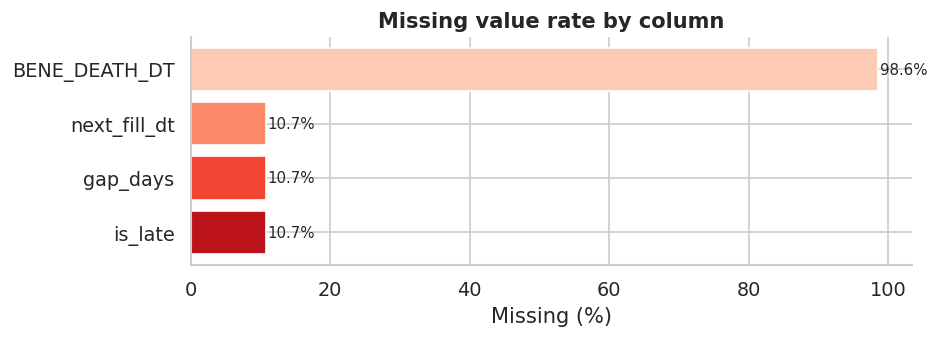

In [8]:
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss) == 0:
    print('✓ No missing values.')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(miss) * 0.35)))
    bars = ax.barh(miss.index[::-1], miss.values[::-1] * 100,
                   color=sns.color_palette('Reds_r', len(miss)))
    for bar, val in zip(bars, miss.values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing value rate by column', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
num_cols = df.select_dtypes(include='number').columns.tolist()
display(df[num_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
QTY_DSPNSD_NUM,5373237.0,50.940269,49.716976,0.0,30.0,30.0,60.0,360.0
DAYS_SUPLY_NUM,5373237.0,34.926437,20.598112,10.0,30.0,30.0,30.0,90.0
PTNT_PAY_AMT,5373237.0,10.388509,23.919415,0.0,0.0,0.0,10.0,170.0
TOT_RX_CST_AMT,5373237.0,61.927303,94.689255,0.0,10.0,20.0,80.0,570.0
days_supply_missing_flag,5373237.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BENE_SEX_IDENT_CD,5373237.0,1.610125,0.487722,1.0,1.0,2.0,2.0,2.0
BENE_RACE_CD,5373237.0,1.322764,0.827455,1.0,1.0,1.0,1.0,5.0
SP_STATE_CODE,5373237.0,25.429911,15.495635,1.0,10.0,25.0,39.0,54.0
BENE_COUNTY_CD,5373237.0,378.027008,264.885376,0.0,150.0,350.0,564.0,999.0
SP_ALZHDMTA,5373237.0,0.216959,0.412175,0.0,0.0,0.0,0.0,1.0


---
## 3. Temporal Patterns

How prescription activity is distributed over time:

- Monthly claim volume (2008–2010) — includes the 2010 truncation artefact
- Day-of-week and month seasonality
- Days-supply distribution (30/60/90-day fills dominate)


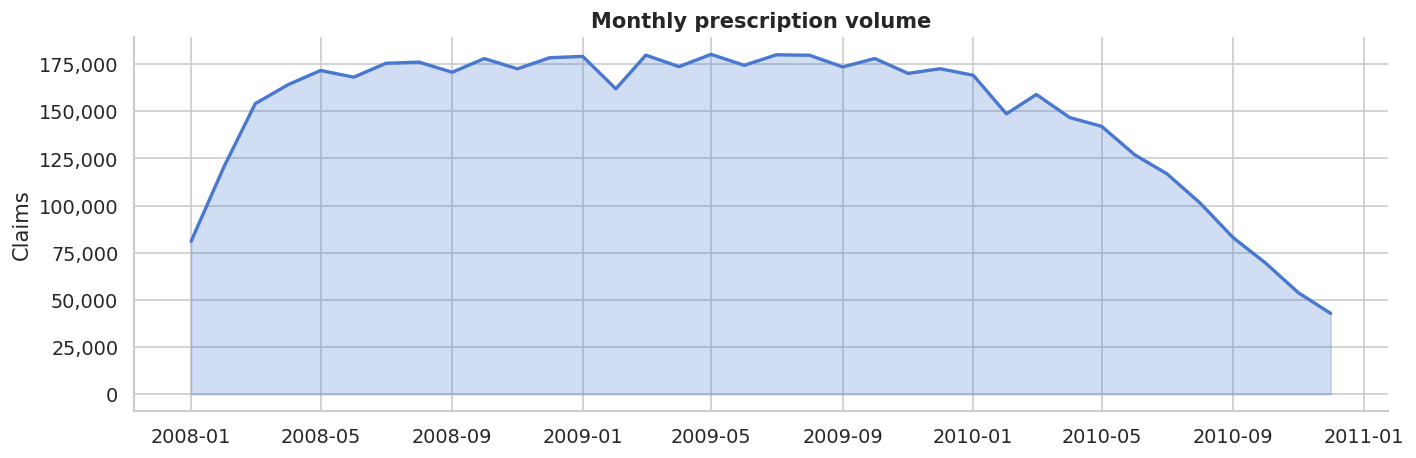

In [10]:
df['year_month'] = df['SRVC_DT'].dt.to_period('M')
monthly = df.groupby('year_month').size().reset_index(name='claims')
monthly['dt'] = monthly['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly['dt'], monthly['claims'], alpha=0.25, color=PALETTE[0])
ax.plot(monthly['dt'], monthly['claims'], color=PALETTE[0], lw=2)
ax.set_title('Monthly prescription volume', fontweight='bold')
ax.set_ylabel('Claims')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

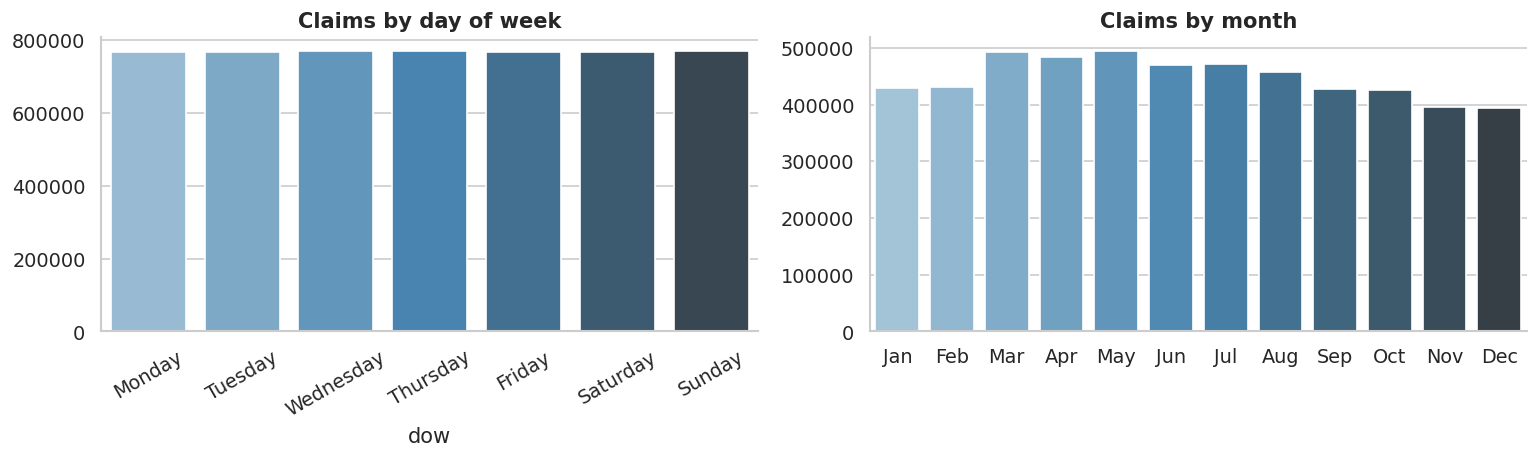

In [11]:
df['dow']   = df['SRVC_DT'].dt.day_name()
df['month'] = df['SRVC_DT'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['dow'].value_counts().reindex(dow_order)
sns.barplot(x=dow_counts.index, y=dow_counts.values,
            ax=axes[0], palette='Blues_d', order=dow_order)
axes[0].set_title('Claims by day of week', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df['month'].value_counts().sort_index()
sns.barplot(x=[month_labels[m-1] for m in month_counts.index],
            y=month_counts.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Claims by month', fontweight='bold')

plt.tight_layout()
plt.show()

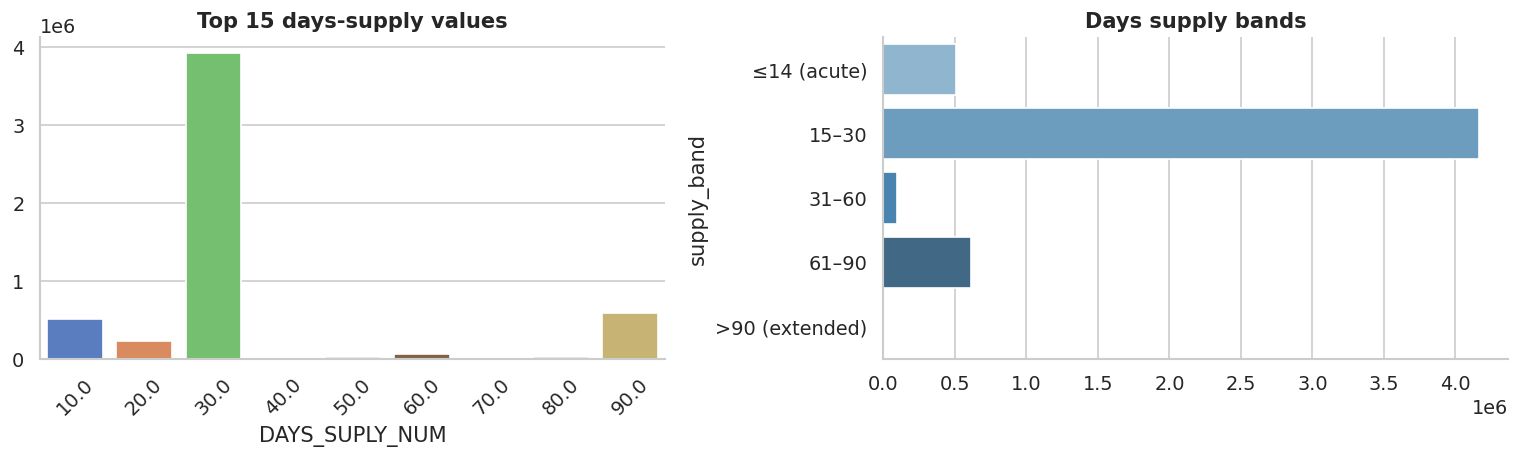

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top_days = df['DAYS_SUPLY_NUM'].value_counts().head(15).sort_index()
sns.barplot(x=top_days.index.astype(str), y=top_days.values,
            ax=axes[0], palette='muted')
axes[0].set_title('Top 15 days-supply values', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

bins   = [0, 14, 30, 60, 90, 999]
labels = ['≤14 (acute)', '15–30', '31–60', '61–90', '>90 (extended)']
df['supply_band'] = pd.cut(df['DAYS_SUPLY_NUM'], bins=bins, labels=labels)
band_counts = df['supply_band'].value_counts().reindex(labels)
sns.barplot(y=band_counts.index, x=band_counts.values,
            ax=axes[1], palette='Blues_d')
axes[1].set_title('Days supply bands', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Patient Demographics

One row per patient (`drop_duplicates` on `DESYNPUF_ID`):

- Age distribution at first fill
- Sex and race breakdown
- Mortality and ESRD prevalence
- Age stratified by sex


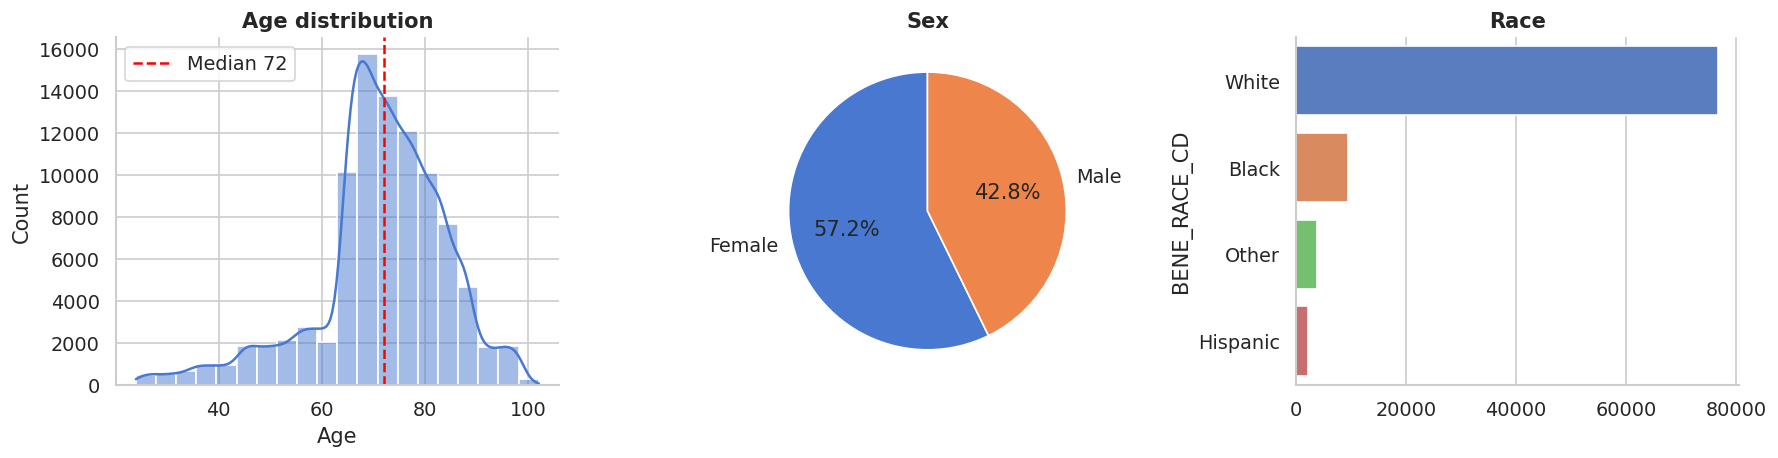

In [31]:
pt_df = df.drop_duplicates(subset=['DESYNPUF_ID'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(pt_df['Age'].dropna(), bins=20, kde=True,
             color=PALETTE[0], ax=axes[0])
axes[0].axvline(pt_df['Age'].median(), color='red', lw=1.5, linestyle='--',
                label=f'Median {pt_df["Age"].median():.0f}')
axes[0].set_title('Age distribution', fontweight='bold')
axes[0].legend()

sex_map = {1: 'Male', 2: 'Female'}
sex_counts = pt_df['BENE_SEX_IDENT_CD'].astype(str).map(lambda x: sex_map.get(int(float(x)), x)).value_counts()
axes[1].pie(sex_counts.values, labels=sex_counts.index,
            autopct='%1.1f%%', colors=PALETTE[:2], startangle=90)
axes[1].set_title('Sex', fontweight='bold')

race_map = {1:'White',2:'Black',3:'Other',5:'Hispanic'}
race_counts = pt_df['BENE_RACE_CD'].astype(str).map(lambda x: race_map.get(int(float(x)), x)).value_counts()
sns.barplot(y=race_counts.index, x=race_counts.values,
            ax=axes[2], palette='muted')
axes[2].set_title('Race', fontweight='bold')

plt.tight_layout()
plt.show()

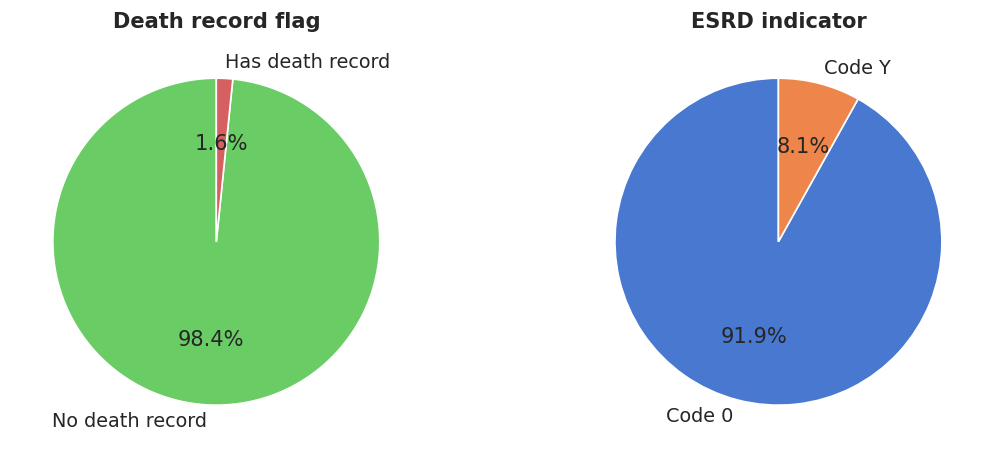

In [32]:
# ── Mortality & ESRD ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Death record flag
death_counts = pt_df['has_death_record'].value_counts()
axes[0].pie(death_counts.values,
            labels=['No death record','Has death record'],
            autopct='%1.1f%%', colors=[PALETTE[2], PALETTE[3]], startangle=90)
axes[0].set_title('Death record flag', fontweight='bold')

# ESRD indicator
esrd_counts = pt_df['BENE_ESRD_IND'].value_counts()
axes[1].pie(esrd_counts.values,
            labels=[f'Code {c}' for c in esrd_counts.index],
            autopct='%1.1f%%', colors=PALETTE, startangle=90)
axes[1].set_title('ESRD indicator', fontweight='bold')

plt.tight_layout()
plt.show()

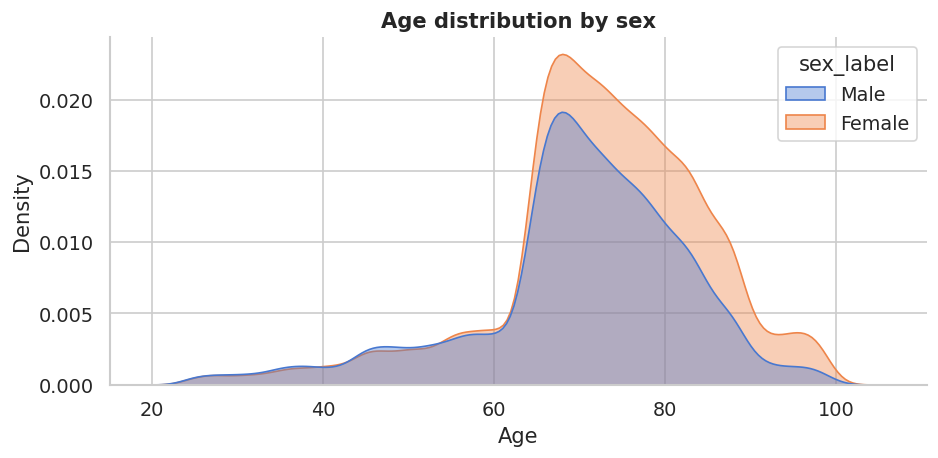

In [33]:
# ── Age by sex ────────────────────────────────────────────────────────────────
pt_df['sex_label'] = pt_df['BENE_SEX_IDENT_CD'].map(sex_map)
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=pt_df, x='Age', hue='sex_label', ax=ax, fill=True, alpha=0.4)
ax.set_title('Age distribution by sex', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Drug & Dispensing Behaviour

- Top 20 ingredients by claim volume
- Quantity dispensed distribution
- Claims per patient (long-tail behaviour)
- Drug metadata distributions (ingredient, route, dosage, packaging)


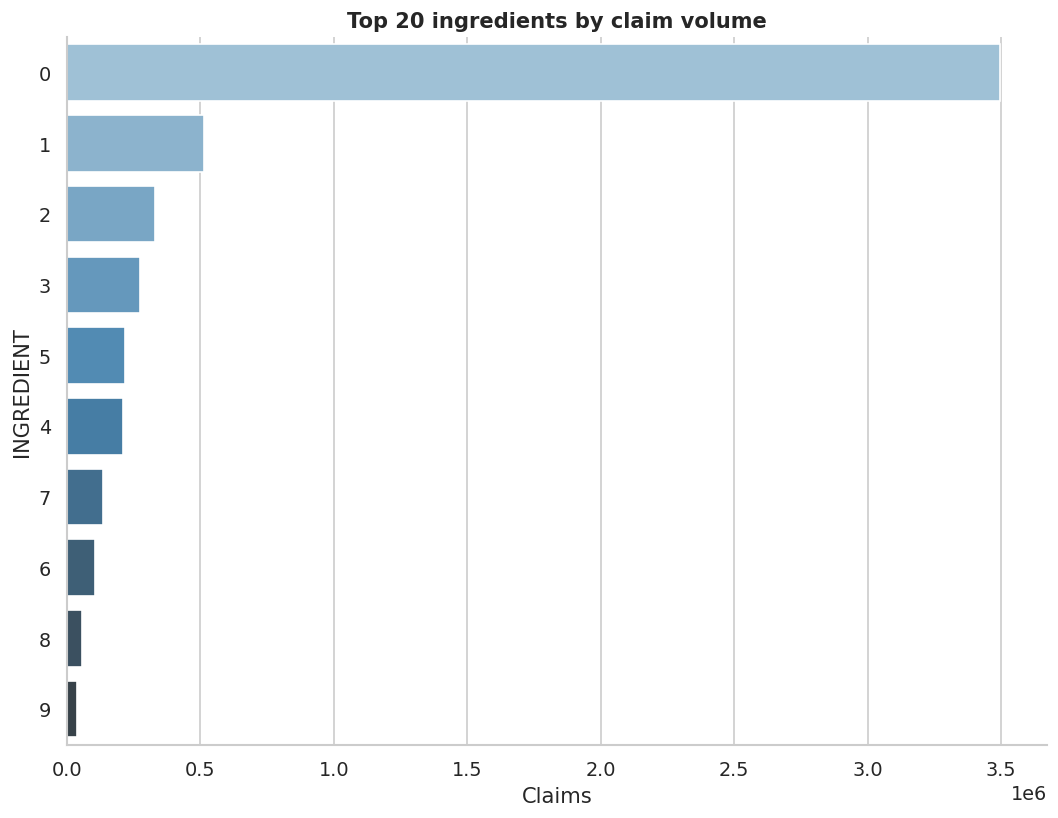

Top 20 cover 100.0% of all claims


In [14]:
# Top 20 ingredients by claim volume
top_ing = df['INGREDIENT'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(y=top_ing.index, x=top_ing.values, ax=ax, palette='Blues_d')
ax.set_title('Top 20 ingredients by claim volume', fontweight='bold')
ax.set_xlabel('Claims')
plt.tight_layout()
plt.show()

print(f'Top 20 cover {top_ing.sum()/len(df)*100:.1f}% of all claims')

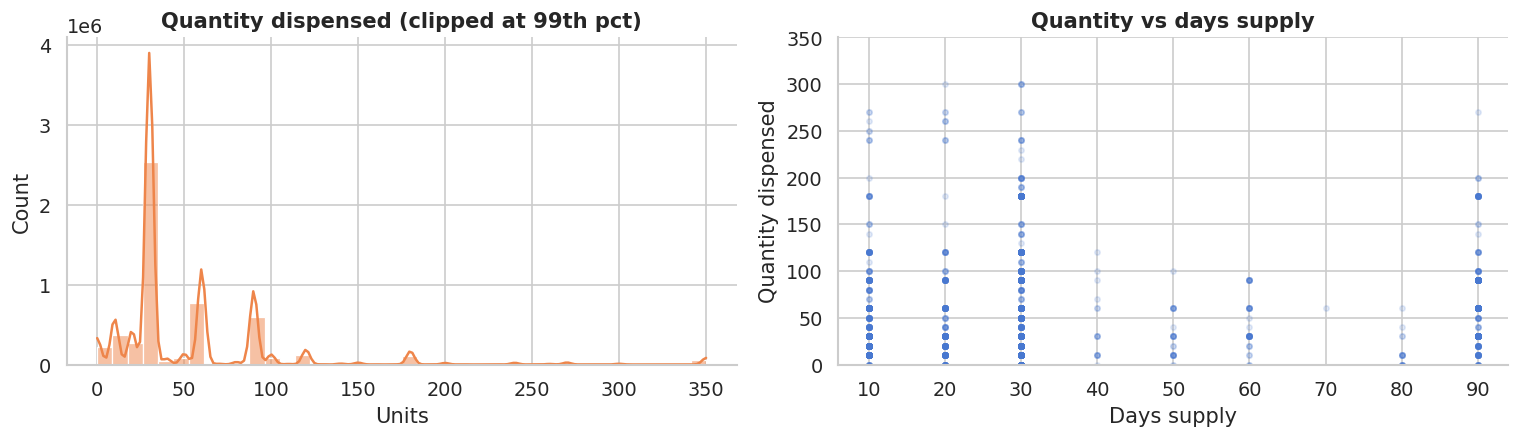

In [35]:
# ── Quantity dispensed distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['QTY_DSPNSD_NUM'].clip(upper=df['QTY_DSPNSD_NUM'].quantile(0.99)),
             bins=40, ax=axes[0], color=PALETTE[1], kde=True)
axes[0].set_title('Quantity dispensed (clipped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Units')

# Quantity vs days supply
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['DAYS_SUPLY_NUM'], sample['QTY_DSPNSD_NUM'],
                alpha=0.15, s=10, color=PALETTE[0])
axes[1].set_title('Quantity vs days supply', fontweight='bold')
axes[1].set_xlabel('Days supply')
axes[1].set_ylabel('Quantity dispensed')
axes[1].set_ylim(0, df['QTY_DSPNSD_NUM'].quantile(0.99))

plt.tight_layout()
plt.show()

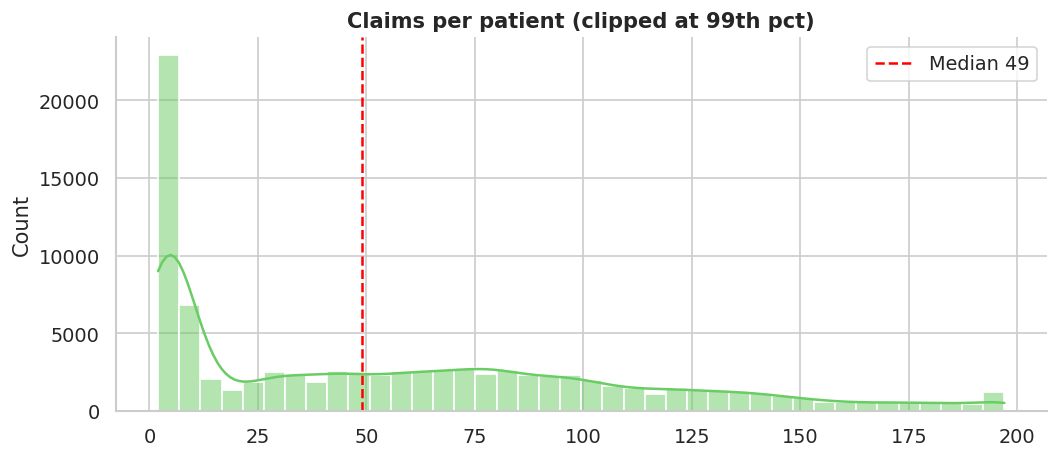

In [15]:
# Claims per patient distribution
claims_per_pt = df.groupby('DESYNPUF_ID').size()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(claims_per_pt.clip(upper=claims_per_pt.quantile(0.99)),
             bins=40, kde=True, color=PALETTE[2], ax=ax)
ax.axvline(claims_per_pt.median(), color='red', lw=1.5, linestyle='--',
           label=f'Median {claims_per_pt.median():.0f}')
ax.set_title('Claims per patient (clipped at 99th pct)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
print(claims_per_pt.describe().round(1))

count    92118.0
mean        58.3
std         53.1
min          2.0
25%          7.0
50%         49.0
75%         94.0
max        249.0
dtype: float64


In [ ]:
# ── Drug metadata distributions (INGREDIENT, ROUTE_ADMIN, DOSAGE) ─────────────kiv
meta_cols = [c for c in ['INGREDIENT','ROUTE_ADMIN','DOSAGE','MANUFACTURER'] if c in df.columns]

for col in meta_cols:
    top = df[col].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(y=top.index, x=top.values, ax=ax, palette='muted')
    ax.set_title(f'Top values — {col}', fontweight='bold')
    ax.set_xlabel('Claims')
    plt.tight_layout()
    plt.show()

---
## 6. Comorbidity Landscape

- Prevalence of each of the 11 `SP_*` chronic condition flags
- Comorbidity count distribution and frailty proxy (`is_frail` = 3+ conditions)
- Co-occurrence heatmap — which conditions appear together
- System-level categorical risk groups (`cat_heart`, `cat_kidney_metabolic`, etc.)


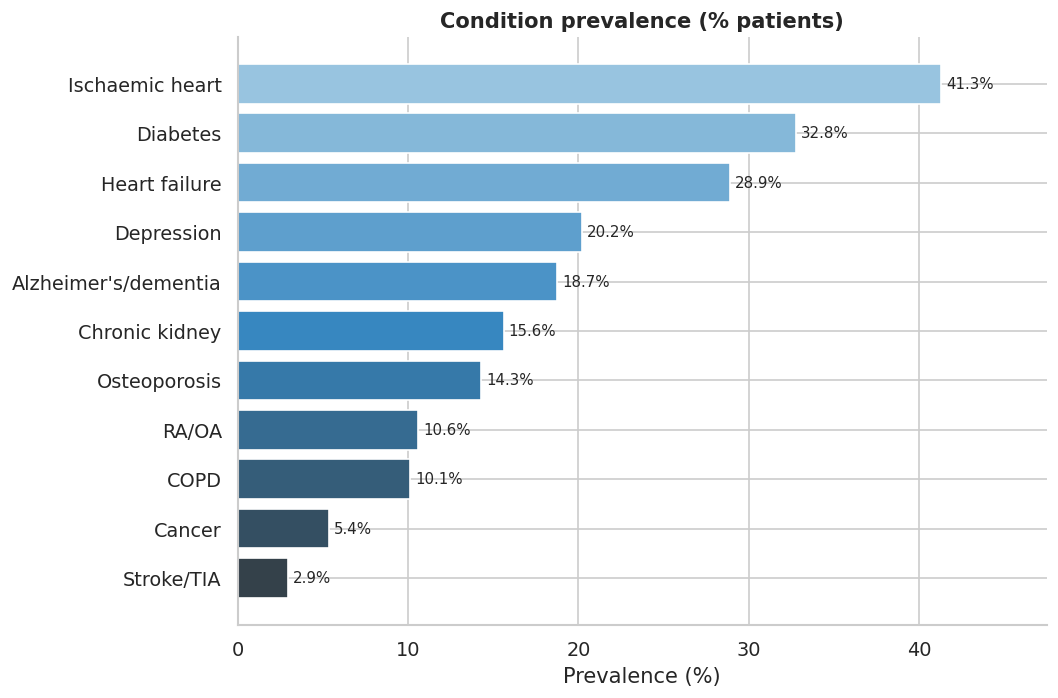

In [16]:
sp_cols = [c for c in df.columns if c.startswith('SP_') and c != 'SP_STATE_CODE']
sp_labels = {
    'SP_ALZHDMTA': "Alzheimer's/dementia", 'SP_CHF': 'Heart failure',
    'SP_CHRNKIDN': 'Chronic kidney',       'SP_CNCR': 'Cancer',
    'SP_COPD'    : 'COPD',                 'SP_DEPRESSN': 'Depression',
    'SP_DIABETES': 'Diabetes',             'SP_ISCHMCHT': 'Ischaemic heart',
    'SP_OSTEOPRS': 'Osteoporosis',         'SP_RA_OA': 'RA/OA',
    'SP_STRKETIA': 'Stroke/TIA',
}

prev = pt_df[sp_cols].mean().rename(index=sp_labels).sort_values() * 100

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(prev.index, prev.values,
               color=sns.color_palette('Blues_d', len(prev))[::-1])
for bar, val in zip(bars, prev.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Condition prevalence (% patients)', fontweight='bold')
ax.set_xlabel('Prevalence (%)')
ax.set_xlim(0, prev.max() * 1.15)
plt.tight_layout()
plt.show()

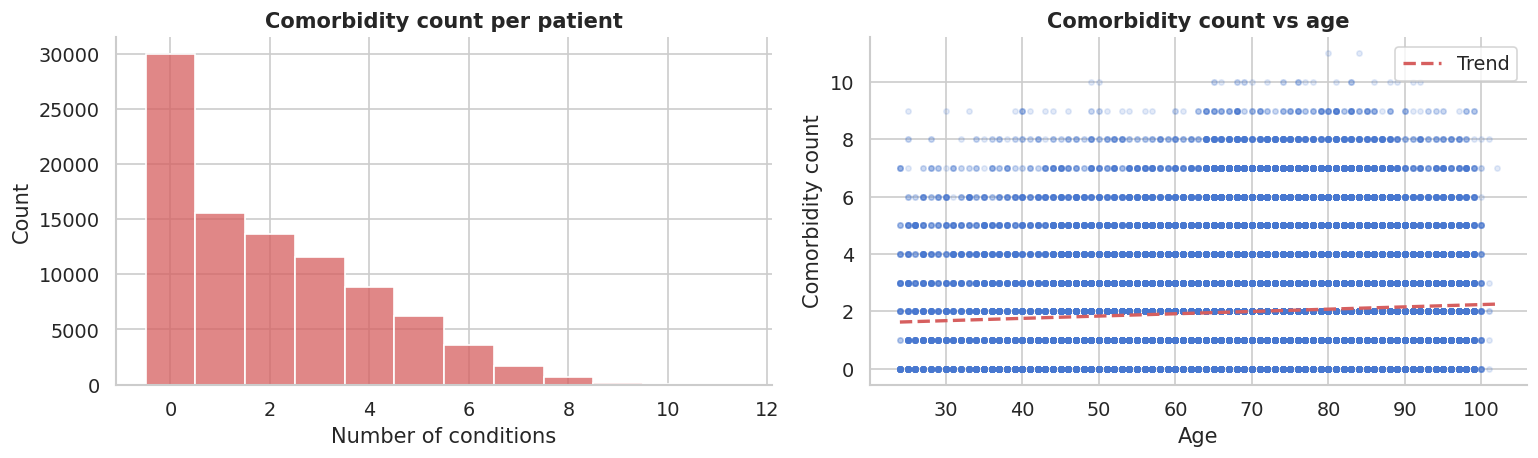

In [37]:
# ── Comorbidity count distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
sns.histplot(pt_df['comorbidity_count'].dropna(), bins=12,
             discrete=True, color=PALETTE[3], ax=axes[0])
axes[0].set_title('Comorbidity count per patient', fontweight='bold')
axes[0].set_xlabel('Number of conditions')

# Comorbidity vs age
axes[1].scatter(pt_df['Age'].dropna(),
                pt_df.loc[pt_df['Age'].notna(), 'comorbidity_count'],
                alpha=0.15, s=10, color=PALETTE[0])
# Trend line
valid = pt_df[['Age','comorbidity_count']].dropna()
z = np.polyfit(valid['Age'], valid['comorbidity_count'], 1)
p = np.poly1d(z)
xs = np.linspace(valid['Age'].min(), valid['Age'].max(), 100)
axes[1].plot(xs, p(xs), 'r--', lw=2, label='Trend')
axes[1].set_title('Comorbidity count vs age', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Comorbidity count')
axes[1].legend()

plt.tight_layout()
plt.show()

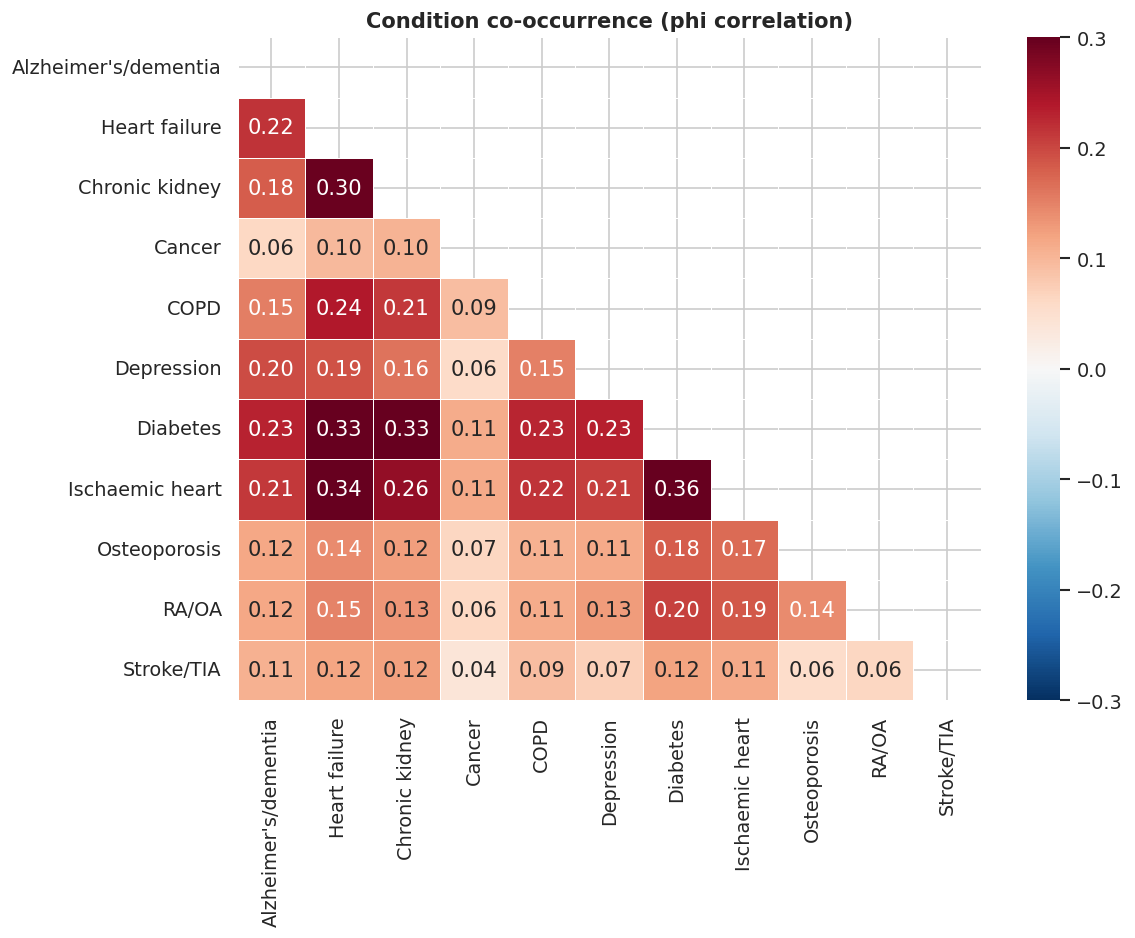

In [17]:
# Co-occurrence heatmap
co = pt_df[sp_cols].rename(columns=sp_labels)
co_corr = co.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(co_corr, dtype=bool))
sns.heatmap(co_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, ax=ax)
ax.set_title('Condition co-occurrence (phi correlation)', fontweight='bold')
plt.tight_layout()
plt.show()

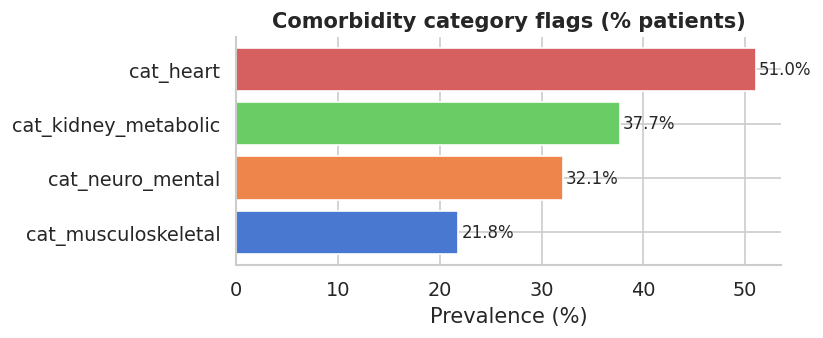

In [38]:
# ── Categorical risk groups ───────────────────────────────────────────────────
cat_cols = [c for c in ['cat_heart','cat_kidney_metabolic','cat_neuro_mental',
                         'cat_musculoskeletal'] if c in df.columns]

if cat_cols:
    cat_prev = pt_df[cat_cols].mean().sort_values(ascending=True) * 100
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(cat_prev.index, cat_prev.values, color=PALETTE[:len(cat_prev)])
    for i, val in enumerate(cat_prev.values):
        ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=10)
    ax.set_title('Comorbidity category flags (% patients)', fontweight='bold')
    ax.set_xlabel('Prevalence (%)')
    plt.tight_layout()
    plt.show()

---
## 7. Financial Signals

- Total cost and patient out-of-pocket distributions (note: CMS values are binned to multiples of $10)
- OOP ratio and insurance benefit amount
- High financial barrier flag (`oop_ratio > 0.50`)


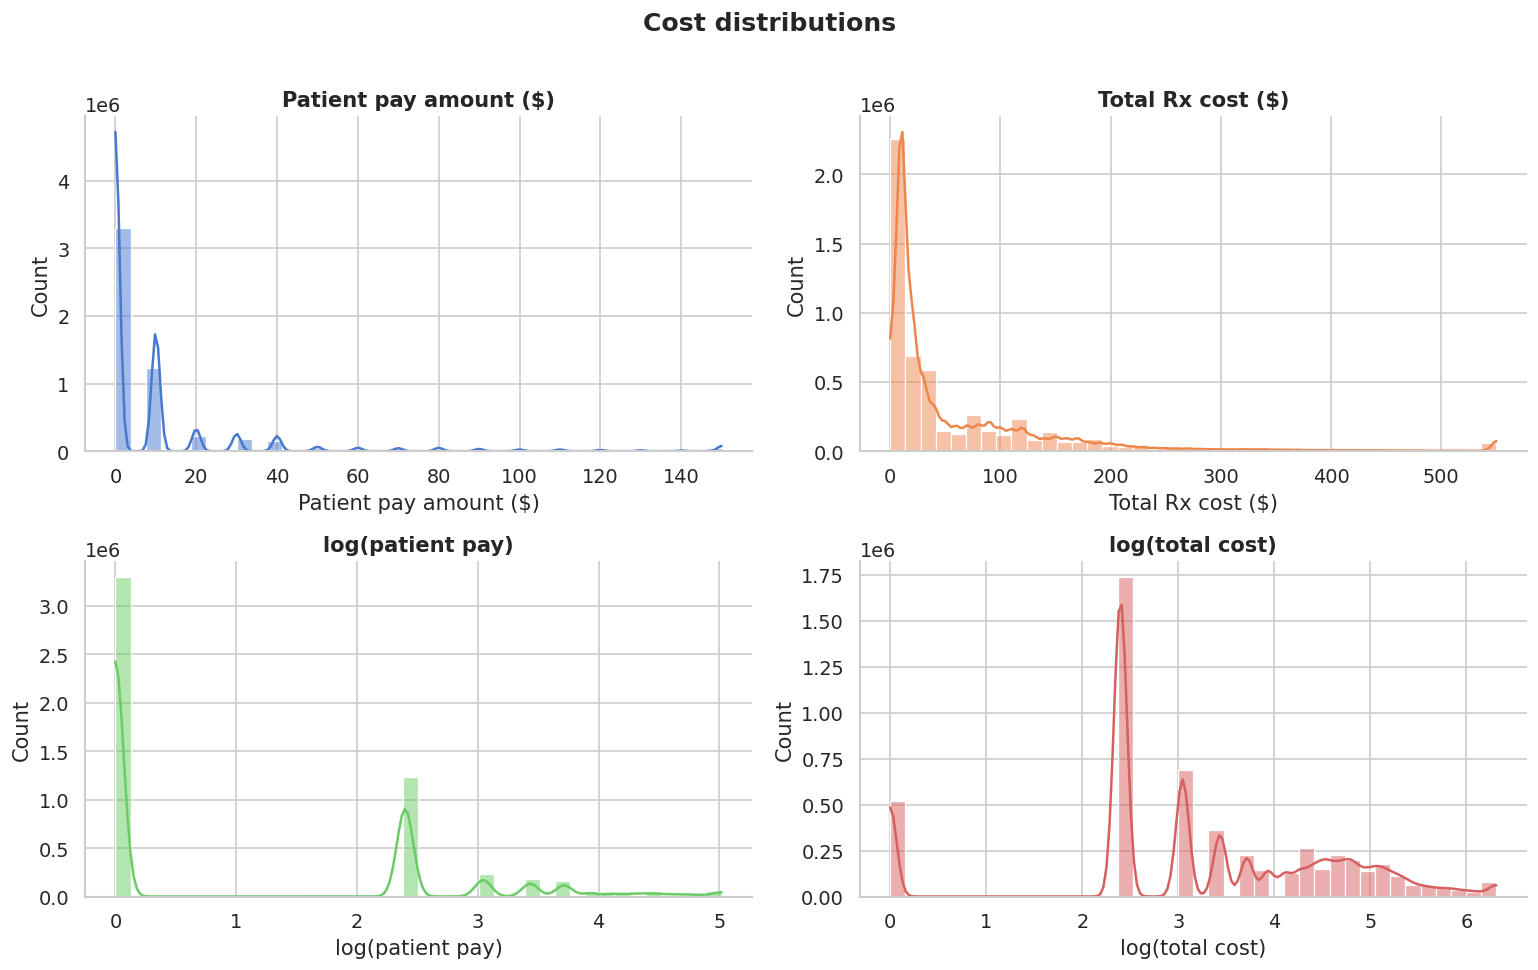

In [39]:
# ── Cost distributions ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (col, label) in enumerate([
    ('PTNT_PAY_AMT',         'Patient pay amount ($)'),
    ('TOT_RX_CST_AMT',       'Total Rx cost ($)'),
    ('log_ptnt_pay',         'log(patient pay)'),
    ('log_tot_cst',          'log(total cost)'),
]):
    if col not in df.columns:
        continue
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    clip_val = data.quantile(0.99)
    sns.histplot(data.clip(upper=clip_val), bins=40, kde=True,
                 color=PALETTE[i], ax=axes[i])
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel(label)

plt.suptitle('Cost distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

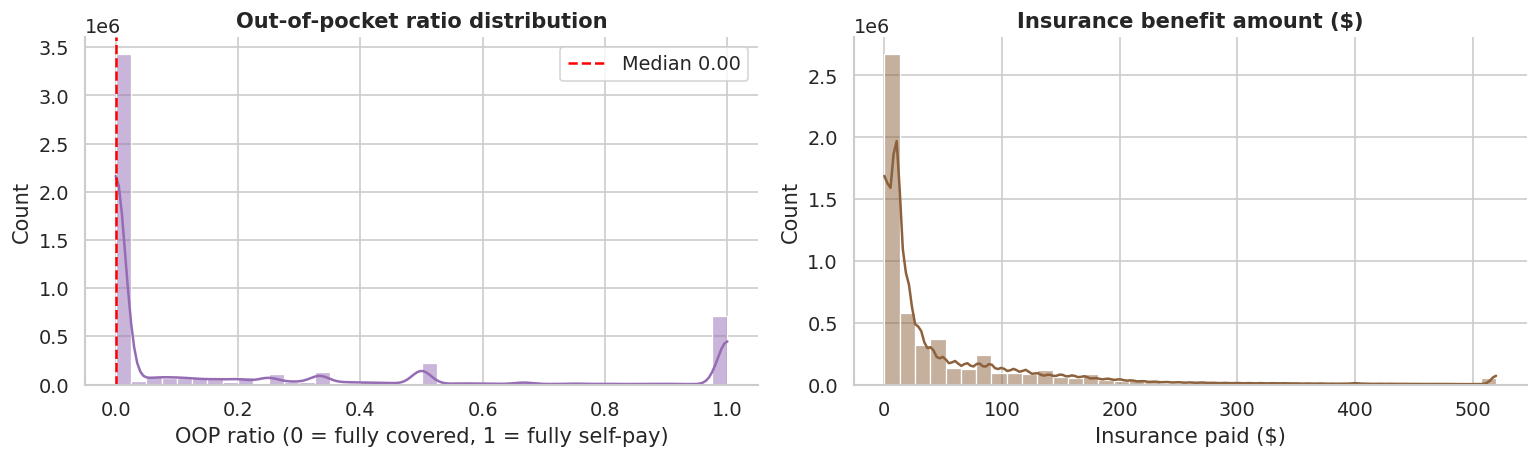

In [40]:
# ── OOP ratio & insurance benefit ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# OOP ratio
oop = df['oop_ratio'].replace([np.inf, -np.inf], np.nan).dropna().clip(0, 1)
sns.histplot(oop, bins=40, kde=True, color=PALETTE[4], ax=axes[0])
axes[0].set_title('Out-of-pocket ratio distribution', fontweight='bold')
axes[0].set_xlabel('OOP ratio (0 = fully covered, 1 = fully self-pay)')
axes[0].axvline(oop.median(), color='red', lw=1.5, linestyle='--',
                label=f'Median {oop.median():.2f}')
axes[0].legend()

# Insurance benefit
ins = df['insurance_benefit_amt'].replace([np.inf, -np.inf], np.nan).dropna()
sns.histplot(ins.clip(upper=ins.quantile(0.99)), bins=40, kde=True,
             color=PALETTE[5], ax=axes[1])
axes[1].set_title('Insurance benefit amount ($)', fontweight='bold')
axes[1].set_xlabel('Insurance paid ($)')

plt.tight_layout()
plt.show()

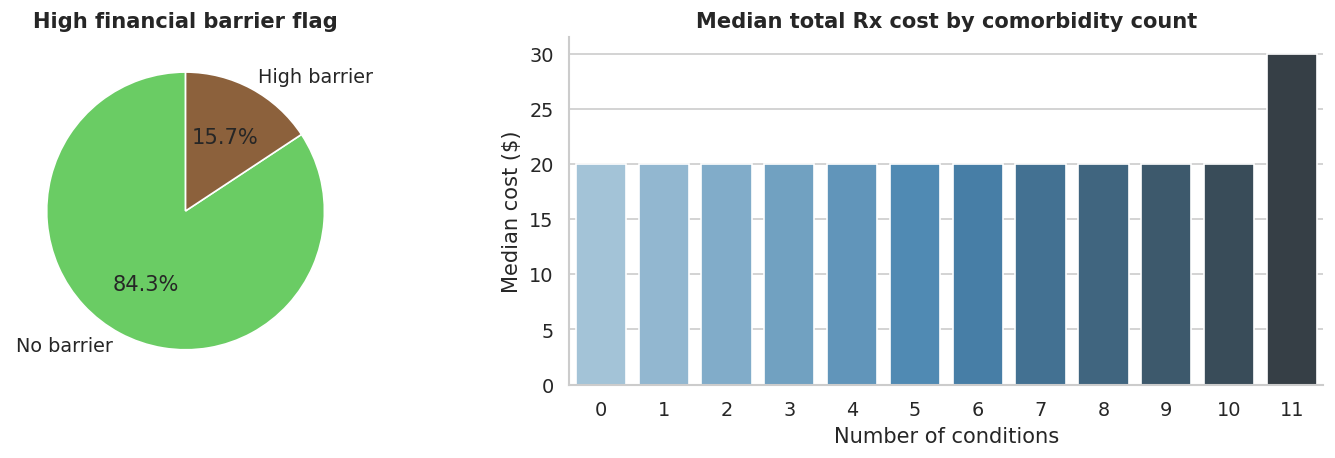

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# High financial barrier flag pie chart on axes[0]
barrier = df['flag_high_financial_barrier'].value_counts()
axes[0].pie(barrier.values, labels=['No barrier','High barrier'],
       autopct='%1.1f%%', colors=[PALETTE[2], PALETTE[5]], startangle=90)
axes[0].set_title('High financial barrier flag', fontweight='bold')

cost_by_cc = df.groupby('comorbidity_count')['TOT_RX_CST_AMT'].median().reset_index()
sns.barplot(data=cost_by_cc, x='comorbidity_count', y='TOT_RX_CST_AMT',
            ax=axes[1], palette='Blues_d')
axes[1].set_title('Median total Rx cost by comorbidity count', fontweight='bold')
axes[1].set_xlabel('Number of conditions')
axes[1].set_ylabel('Median cost ($)')

plt.tight_layout()
plt.show()

---
## 8. Engineered Flags

Audit of all binary flags created during feature engineering:

- Prevalence of every `flag_*` and `is_*` column
- Frailty breakdown by comorbidity count
- Days-supply missing flag rate


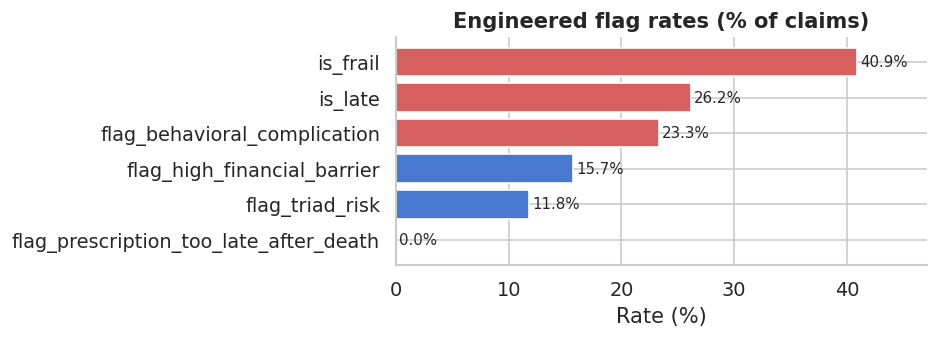

In [42]:
# ── Binary flag summary ───────────────────────────────────────────────────────
flag_cols = [c for c in df.columns if c.startswith('flag_') or c.startswith('is_')]

flag_rates = df[flag_cols].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(8, max(3, len(flag_rates) * 0.45)))
colors = [PALETTE[3] if v > 20 else PALETTE[0] for v in flag_rates.values]
bars = ax.barh(flag_rates.index, flag_rates.values, color=colors)
for bar, val in zip(bars, flag_rates.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Engineered flag rates (% of claims)', fontweight='bold')
ax.set_xlabel('Rate (%)')
ax.set_xlim(0, flag_rates.max() * 1.15)
plt.tight_layout()
plt.show()

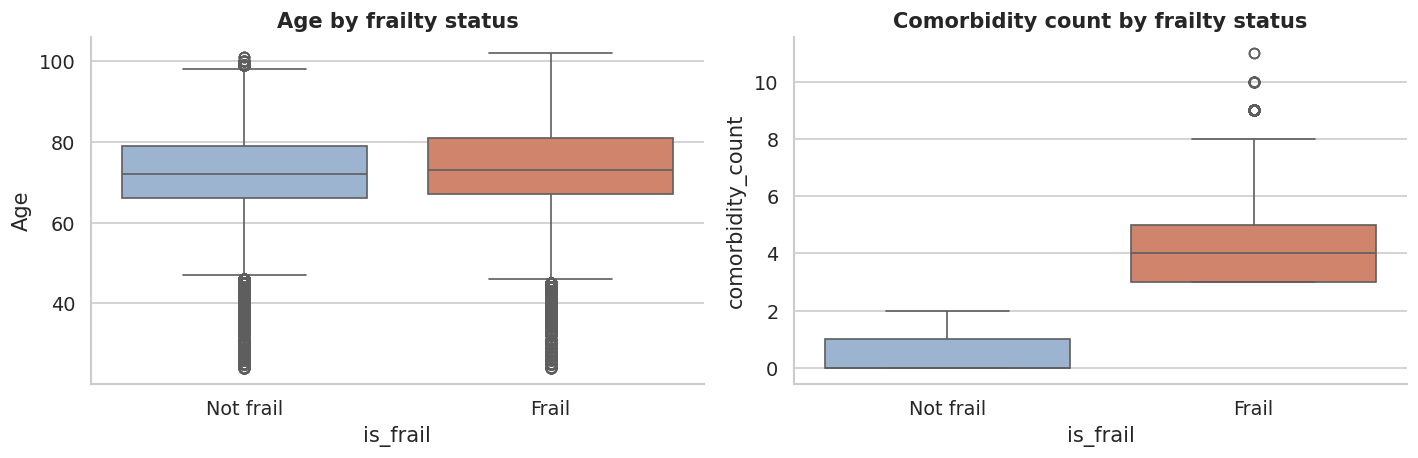

In [43]:
# ── Frailty flag breakdown ────────────────────────────────────────────────────
if 'is_frail' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Frailty vs age
    sns.boxplot(data=pt_df, x='is_frail', y='Age',
                palette=['#94b4d8','#e07b5a'], ax=axes[0])
    axes[0].set_xticklabels(['Not frail', 'Frail'])
    axes[0].set_title('Age by frailty status', fontweight='bold')

    # Frailty vs comorbidity count
    sns.boxplot(data=pt_df, x='is_frail', y='comorbidity_count',
                palette=['#94b4d8','#e07b5a'], ax=axes[1])
    axes[1].set_xticklabels(['Not frail', 'Frail'])
    axes[1].set_title('Comorbidity count by frailty status', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [44]:
# ── Days supply missing flag ──────────────────────────────────────────────────
if 'days_supply_missing_flag' in df.columns:
    miss_rate = df['days_supply_missing_flag'].mean() * 100
    print(f'Days supply missing flag rate: {miss_rate:.2f}%')
    print(df.groupby('days_supply_missing_flag')[['DAYS_SUPLY_NUM','TOT_RX_CST_AMT']].median().round(2))

Days supply missing flag rate: 0.00%
                          DAYS_SUPLY_NUM  TOT_RX_CST_AMT
days_supply_missing_flag                                
0                                   30.0            20.0


---
## 9. Late Refiller Analysis

All charts in this section use only **labelled fills** (`MISSES != 'NA'`) — i.e. fills that have a subsequent fill to evaluate against.

Sub-sections:

- **9a** Overall late rate and gap distribution
- **9b** Grace window sensitivity (0 / 3 / 7 / 14 / 30 days)
- **9c** Late rate by days-supply band
- **9d** Late rate by top ingredients
- **9e** Late rate by comorbidity count
- **9f** Late rate by chronic condition
- **9g** Late rate by financial barrier and frailty
- **9h** Monthly late rate trend
- **9i** Late refiller patient profile (aggregate)
- **9j** Gap days distribution by MISSES class


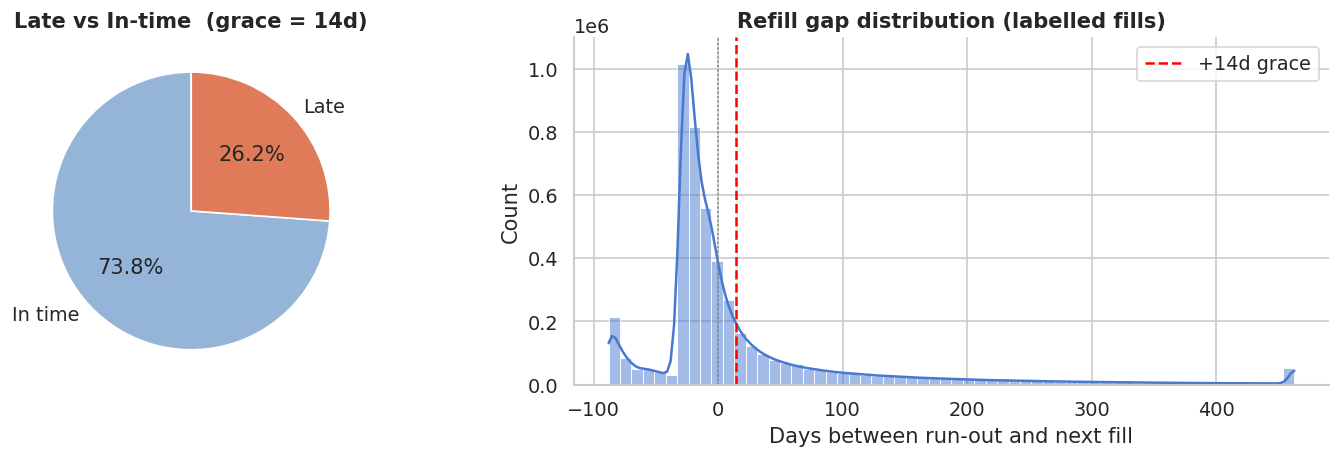

Gap days stats (labelled fills):
count    4795824.0
mean          17.3
std           99.1
min          -90.0
25%          -26.0
50%          -13.0
75%           17.0
max         1056.0

% negative gap (refilled early)   : 64.7%
% gap 0–14d (on time)          : 9.1%
% gap >14d (late)               : 26.2%


In [20]:
# ── 9a. Overall late rate & gap distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MISSES breakdown pie
misses_counts = labelled['MISSES'].value_counts()
axes[0].pie(misses_counts.values,
            labels=misses_counts.index,
            autopct='%1.1f%%',
            colors=['#94b4d8', '#e07b5a'],
            startangle=90)
axes[0].set_title(f'Late vs In-time  (grace = {GRACE_DAYS}d)',
                  fontweight='bold')

# Gap days distribution
gap_clip = labelled['gap_days'].clip(
    labelled['gap_days'].quantile(0.01),
    labelled['gap_days'].quantile(0.99)
)
sns.histplot(gap_clip, bins=60, kde=True, color=PALETTE[0], ax=axes[1])
axes[1].axvline(GRACE_DAYS, color='red', lw=1.5, linestyle='--',
                label=f'+{GRACE_DAYS}d grace')
axes[1].axvline(0, color='grey', lw=1, linestyle=':')
axes[1].set_title('Refill gap distribution (labelled fills)', fontweight='bold')
axes[1].set_xlabel('Days between run-out and next fill')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Gap days stats (labelled fills):')
print(labelled['gap_days'].describe().round(1).to_string())
print(f'\n% negative gap (refilled early)   : {(labelled["gap_days"] < 0).mean()*100:.1f}%')
print(f'% gap 0–{GRACE_DAYS}d (on time)          : {((labelled["gap_days"] >= 0) & (labelled["gap_days"] <= GRACE_DAYS)).mean()*100:.1f}%')
print(f'% gap >{GRACE_DAYS}d (late)               : {(labelled["gap_days"] > GRACE_DAYS).mean()*100:.1f}%')

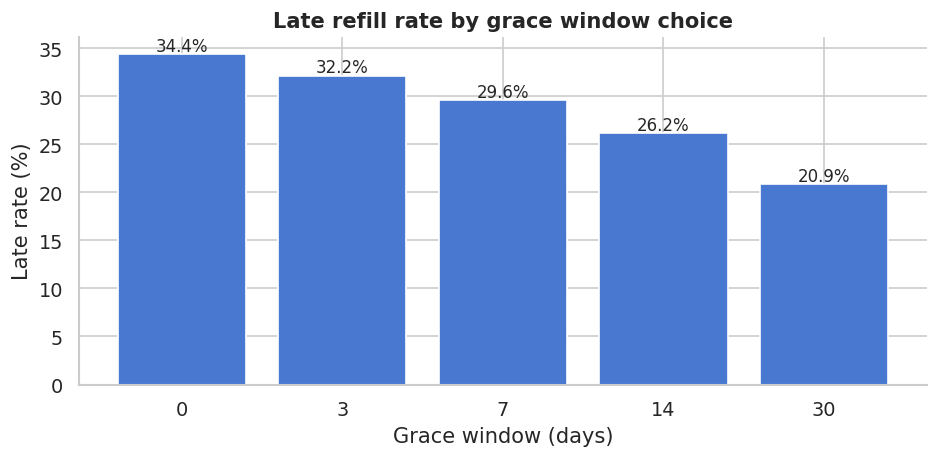

Late rates by grace window:
  grace =  0d → 34.43%
  grace =  3d → 32.16%
  grace =  7d → 29.62%
  grace = 14d → 26.16%
  grace = 30d → 20.89%


In [21]:
# ── 9b. Grace window sensitivity ─────────────────────────────────────────────
grace_options = [0, 3, 7, 14, 30]
late_rates = {
    g: (labelled['gap_days'] > g).mean() * 100
    for g in grace_options
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(g) for g in grace_options], late_rates.values(), color=PALETTE[0])
ax.set_title('Late refill rate by grace window choice', fontweight='bold')
ax.set_xlabel('Grace window (days)')
ax.set_ylabel('Late rate (%)')
for i, (g, r) in enumerate(late_rates.items()):
    ax.text(i, r + 0.3, f'{r:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('Late rates by grace window:')
for g, r in late_rates.items():
    print(f'  grace = {g:2d}d → {r:.2f}%')

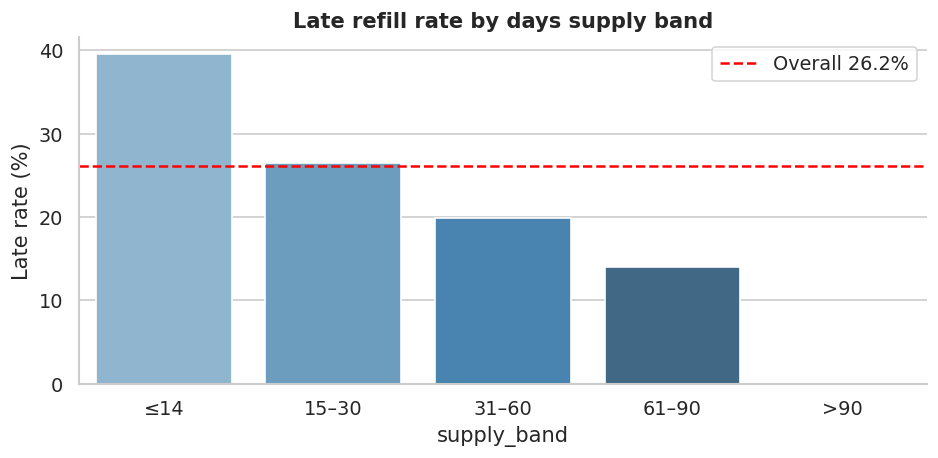

In [22]:
# ── 9c. Late rate by days supply band ────────────────────────────────────────
labelled['supply_band'] = pd.cut(
    labelled['DAYS_SUPLY_NUM'],
    bins=[0, 14, 30, 60, 90, 999],
    labels=['≤14', '15–30', '31–60', '61–90', '>90']
)
late_by_band = labelled.groupby('supply_band', observed=True)['is_late'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=late_by_band.index, y=late_by_band.values,
            ax=ax, palette='Blues_d')
ax.axhline(late_rate, color='red', lw=1.5, linestyle='--',
           label=f'Overall {late_rate:.1f}%')
ax.set_title('Late refill rate by days supply band', fontweight='bold')
ax.set_ylabel('Late rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

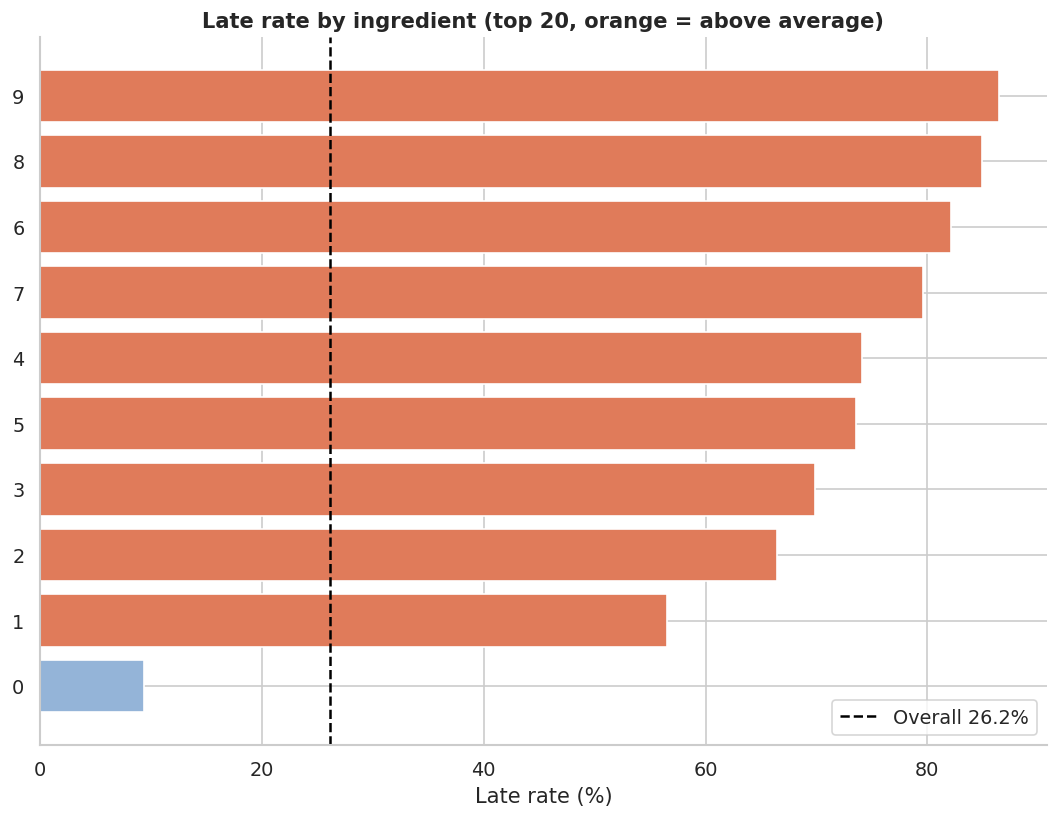

In [23]:
# ── 9d. Late rate by top ingredients ────────────────────────────────────────
top_ings = labelled['INGREDIENT'].value_counts().head(20).index
late_by_ing = (
    labelled[labelled['INGREDIENT'].isin(top_ings)]
    .groupby('INGREDIENT')['is_late'].mean()
    .sort_values(ascending=True) * 100
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e07b5a' if v > late_rate else '#94b4d8' for v in late_by_ing.values]
ax.barh(late_by_ing.index, late_by_ing.values, color=colors)
ax.axvline(late_rate, color='black', lw=1.5, linestyle='--',
           label=f'Overall {late_rate:.1f}%')
ax.set_title('Late rate by ingredient (top 20, orange = above average)',
             fontweight='bold')
ax.set_xlabel('Late rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

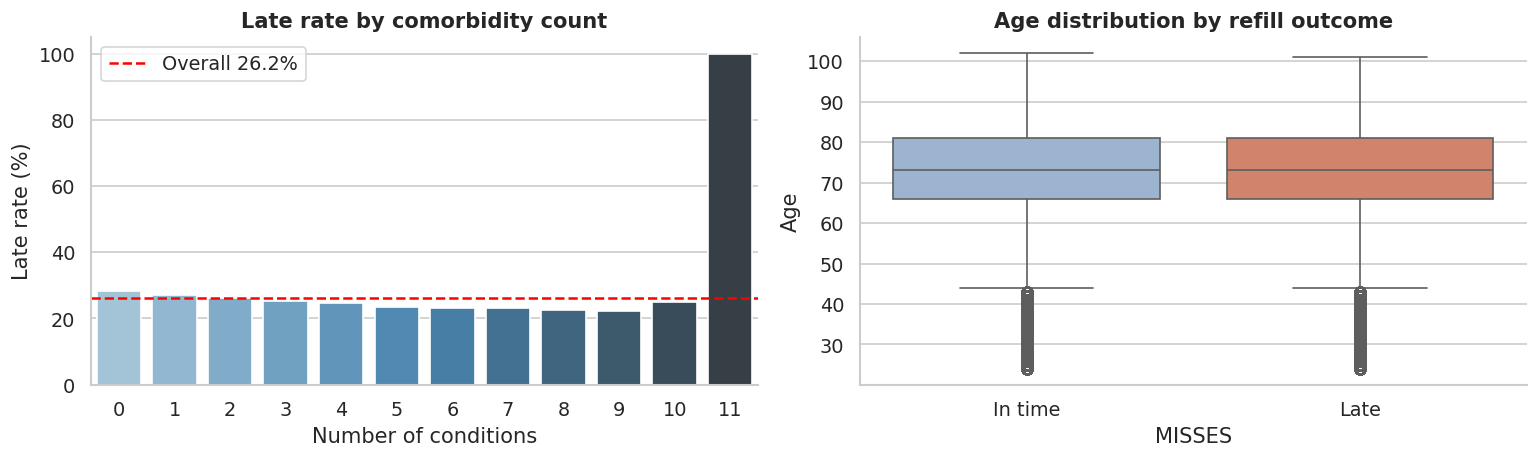

In [24]:
# ── 9e. Late rate by comorbidity count ───────────────────────────────────────
late_by_cc = labelled.groupby('comorbidity_count')['is_late'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=late_by_cc.index, y=late_by_cc.values,
            ax=axes[0], palette='Blues_d')
axes[0].axhline(late_rate, color='red', lw=1.5, linestyle='--',
                label=f'Overall {late_rate:.1f}%')
axes[0].set_title('Late rate by comorbidity count', fontweight='bold')
axes[0].set_xlabel('Number of conditions')
axes[0].set_ylabel('Late rate (%)')
axes[0].legend()

# Age vs is_late boxplot
sns.boxplot(data=labelled, x='MISSES', y='Age',
            order=['In time', 'Late'],
            palette=['#94b4d8', '#e07b5a'], ax=axes[1])
axes[1].set_title('Age distribution by refill outcome', fontweight='bold')

plt.tight_layout()
plt.show()

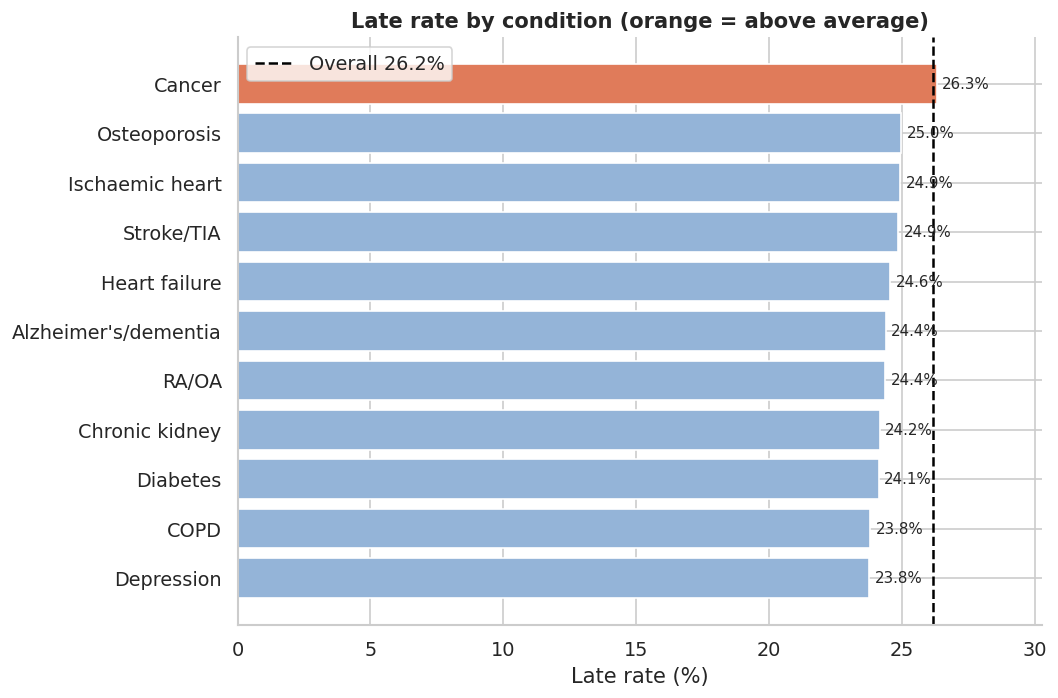

In [25]:
# ── 9f. Late rate by condition ───────────────────────────────────────────────
sp_late = {}
for col in sp_cols:
    label = sp_labels.get(col, col)
    sp_late[label] = labelled[labelled[col] == 1]['is_late'].mean() * 100

sp_late_s = pd.Series(sp_late).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e07b5a' if v > late_rate else '#94b4d8' for v in sp_late_s.values]
ax.barh(sp_late_s.index, sp_late_s.values, color=colors)
ax.axvline(late_rate, color='black', lw=1.5, linestyle='--',
           label=f'Overall {late_rate:.1f}%')
for i, val in enumerate(sp_late_s.values):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Late rate by condition (orange = above average)', fontweight='bold')
ax.set_xlabel('Late rate (%)')
ax.set_xlim(0, sp_late_s.max() * 1.15)
ax.legend()
plt.tight_layout()
plt.show()

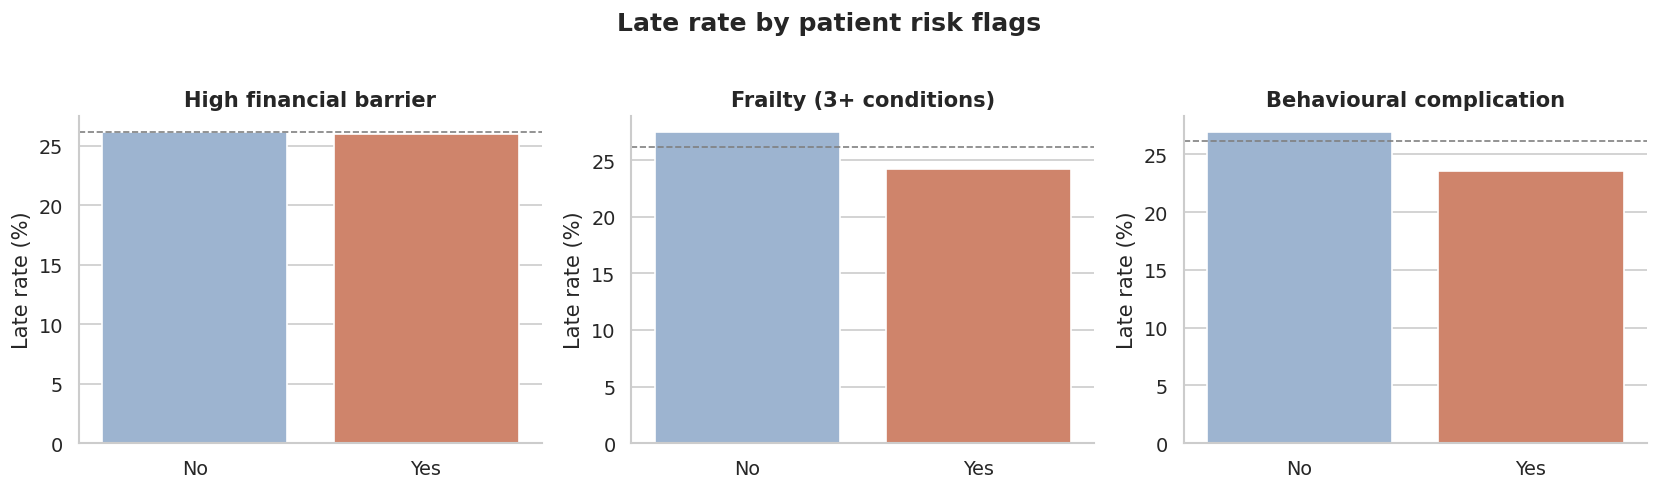

In [26]:
# ── 9g. Late rate by financial barrier & frailty ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in [
    (axes[0], 'flag_high_financial_barrier', 'High financial barrier'),
    (axes[1], 'is_frail',                    'Frailty (3+ conditions)'),
    (axes[2], 'flag_behavioral_complication', 'Behavioural complication'),
]:
    if col not in labelled.columns:
        continue
    rates = labelled.groupby(col)['is_late'].mean() * 100
    labels_map = {0: 'No', 1: 'Yes'}
    sns.barplot(x=[labels_map.get(k, k) for k in rates.index],
                y=rates.values, ax=ax,
                palette=['#94b4d8', '#e07b5a'])
    ax.axhline(late_rate, color='grey', lw=1, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Late rate (%)')

plt.suptitle('Late rate by patient risk flags', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

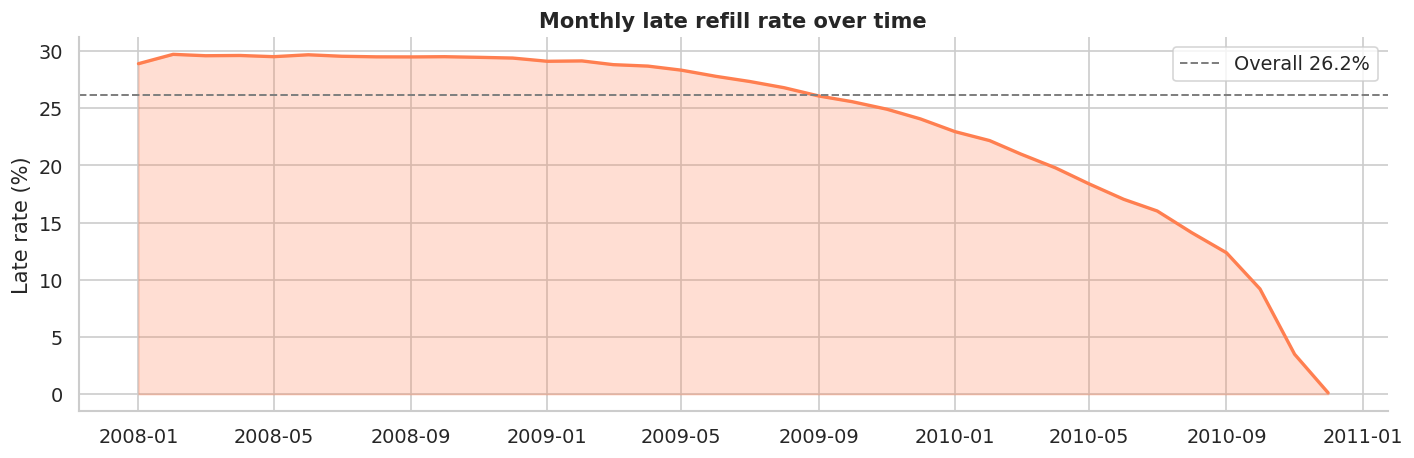

In [27]:
# ── 9h. Monthly late rate trend ──────────────────────────────────────────────
labelled['year_month'] = labelled['SRVC_DT'].dt.to_period('M')
monthly_late = (
    labelled.groupby('year_month')['is_late']
    .agg(late_count='sum', total='count')
    .reset_index()
)
monthly_late['late_rate'] = monthly_late['late_count'] / monthly_late['total'] * 100
monthly_late['dt'] = monthly_late['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly_late['dt'], monthly_late['late_rate'],
                alpha=0.25, color='coral')
ax.plot(monthly_late['dt'], monthly_late['late_rate'],
        color='coral', lw=2)
ax.axhline(late_rate, color='grey', lw=1.2, linestyle='--',
           label=f'Overall {late_rate:.1f}%')
ax.set_title('Monthly late refill rate over time', fontweight='bold')
ax.set_ylabel('Late rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

Patients who are ≥50% late: 29.5%


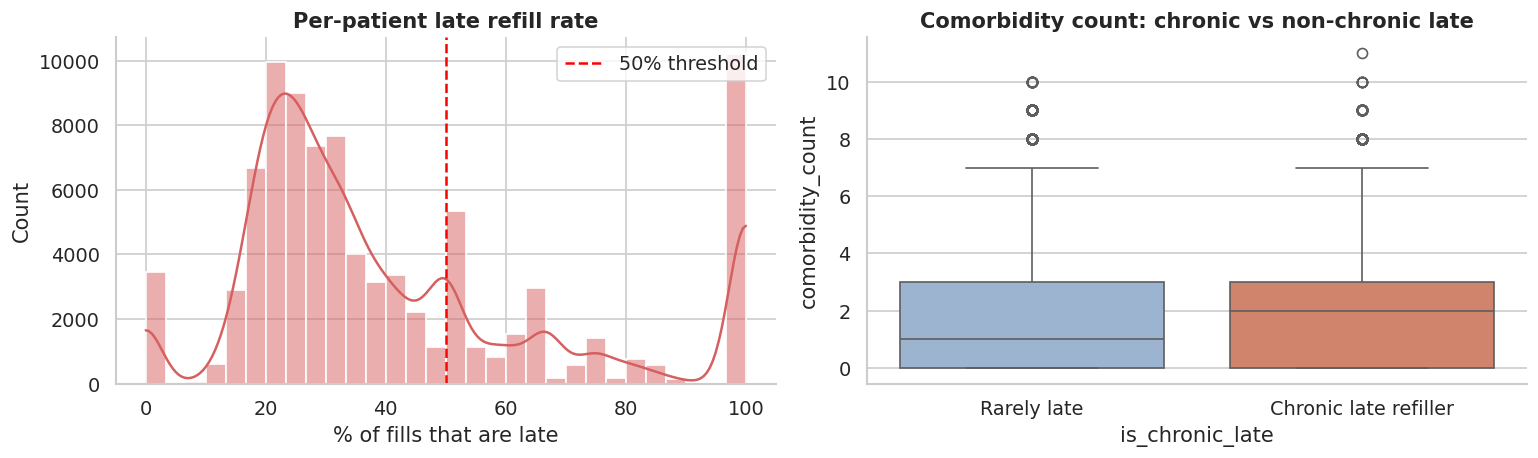

In [28]:
# ── 9i. Late refiller patient profile ────────────────────────────────────────
# Aggregate to patient level: is patient a 'chronic late refiller'?
pt_late = (
    labelled.groupby('DESYNPUF_ID')
    .agg(
        n_labelled_fills  = ('is_late', 'count'),
        n_late            = ('is_late', 'sum'),
        mean_gap          = ('gap_days', 'mean'),
        Age               = ('Age',      'first'),
        comorbidity_count = ('comorbidity_count', 'first'),
        is_frail          = ('is_frail', 'first'),
    )
    .reset_index()
)
pt_late['pt_late_rate'] = pt_late['n_late'] / pt_late['n_labelled_fills'] * 100
pt_late['is_chronic_late'] = (pt_late['pt_late_rate'] >= 50).astype(int)

chronic_pct = pt_late['is_chronic_late'].mean() * 100
print(f'Patients who are ≥50% late: {chronic_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(pt_late['pt_late_rate'], bins=30, kde=True,
             color=PALETTE[3], ax=axes[0])
axes[0].axvline(50, color='red', lw=1.5, linestyle='--', label='50% threshold')
axes[0].set_title('Per-patient late refill rate', fontweight='bold')
axes[0].set_xlabel('% of fills that are late')
axes[0].legend()

sns.boxplot(data=pt_late, x='is_chronic_late', y='comorbidity_count',
            palette=['#94b4d8', '#e07b5a'], ax=axes[1])
axes[1].set_xticklabels(['Rarely late', 'Chronic late refiller'])
axes[1].set_title('Comorbidity count: chronic vs non-chronic late', fontweight='bold')

plt.tight_layout()
plt.show()

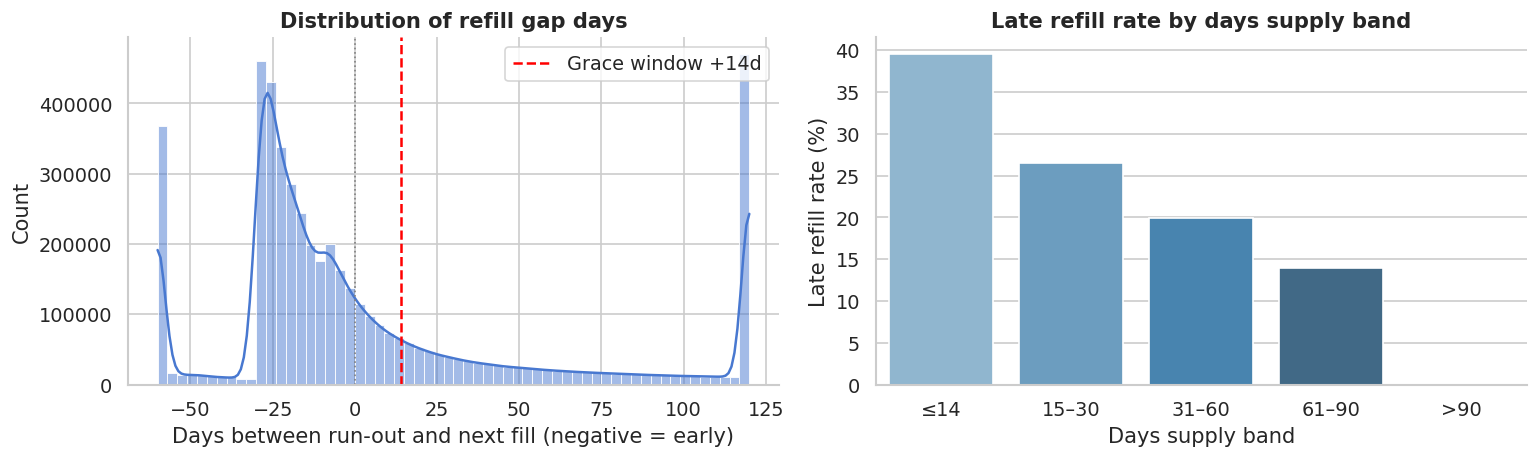

In [48]:
# ── Gap days distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gap_clip = labelled['gap_days'].clip(-60, 120)
sns.histplot(gap_clip, bins=60, kde=True, color=PALETTE[0], ax=axes[0])
axes[0].axvline(GRACE_DAYS, color='red', lw=1.5, linestyle='--',
                label=f'Grace window +{GRACE_DAYS}d')
axes[0].axvline(0, color='grey', lw=1, linestyle=':')
axes[0].set_title('Distribution of refill gap days', fontweight='bold')
axes[0].set_xlabel('Days between run-out and next fill (negative = early)')
axes[0].legend()

# Late rate by days supply band
labelled['supply_band'] = pd.cut(labelled['DAYS_SUPLY_NUM'],
                                  bins=[0,14,30,60,90,999],
                                  labels=['≤14','15–30','31–60','61–90','>90'])
late_by_band = labelled.groupby('supply_band')['is_late'].mean() * 100
sns.barplot(x=late_by_band.index, y=late_by_band.values,
            ax=axes[1], palette='Blues_d')
axes[1].set_title('Late refill rate by days supply band', fontweight='bold')
axes[1].set_xlabel('Days supply band')
axes[1].set_ylabel('Late refill rate (%)')

plt.tight_layout()
plt.show()

---
## 10. Correlation & Multivariate

- Pearson correlation heatmap across key numeric features
- Pairplot of age, comorbidity count, days supply, cost, and OOP ratio (sampled for speed)


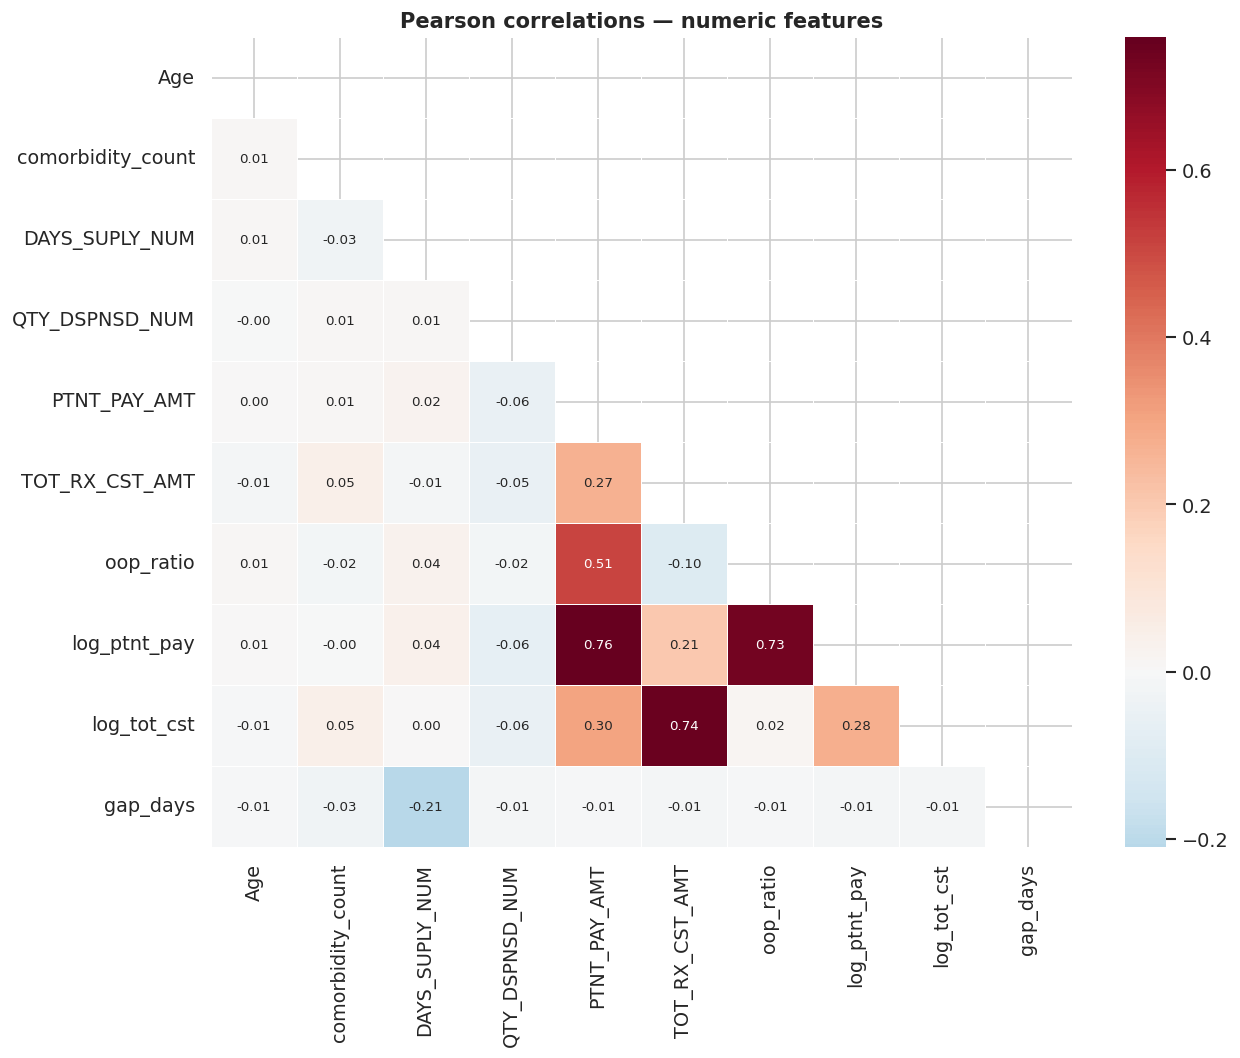

In [29]:
core_num = [
    'Age', 'comorbidity_count', 'DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM',
    'PTNT_PAY_AMT', 'TOT_RX_CST_AMT', 'oop_ratio',
    'log_ptnt_pay', 'log_tot_cst', 'gap_days',
]
core_num = [c for c in core_num if c in labelled.columns]
corr = labelled[core_num].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson correlations — numeric features', fontweight='bold')
plt.tight_layout()
plt.show()

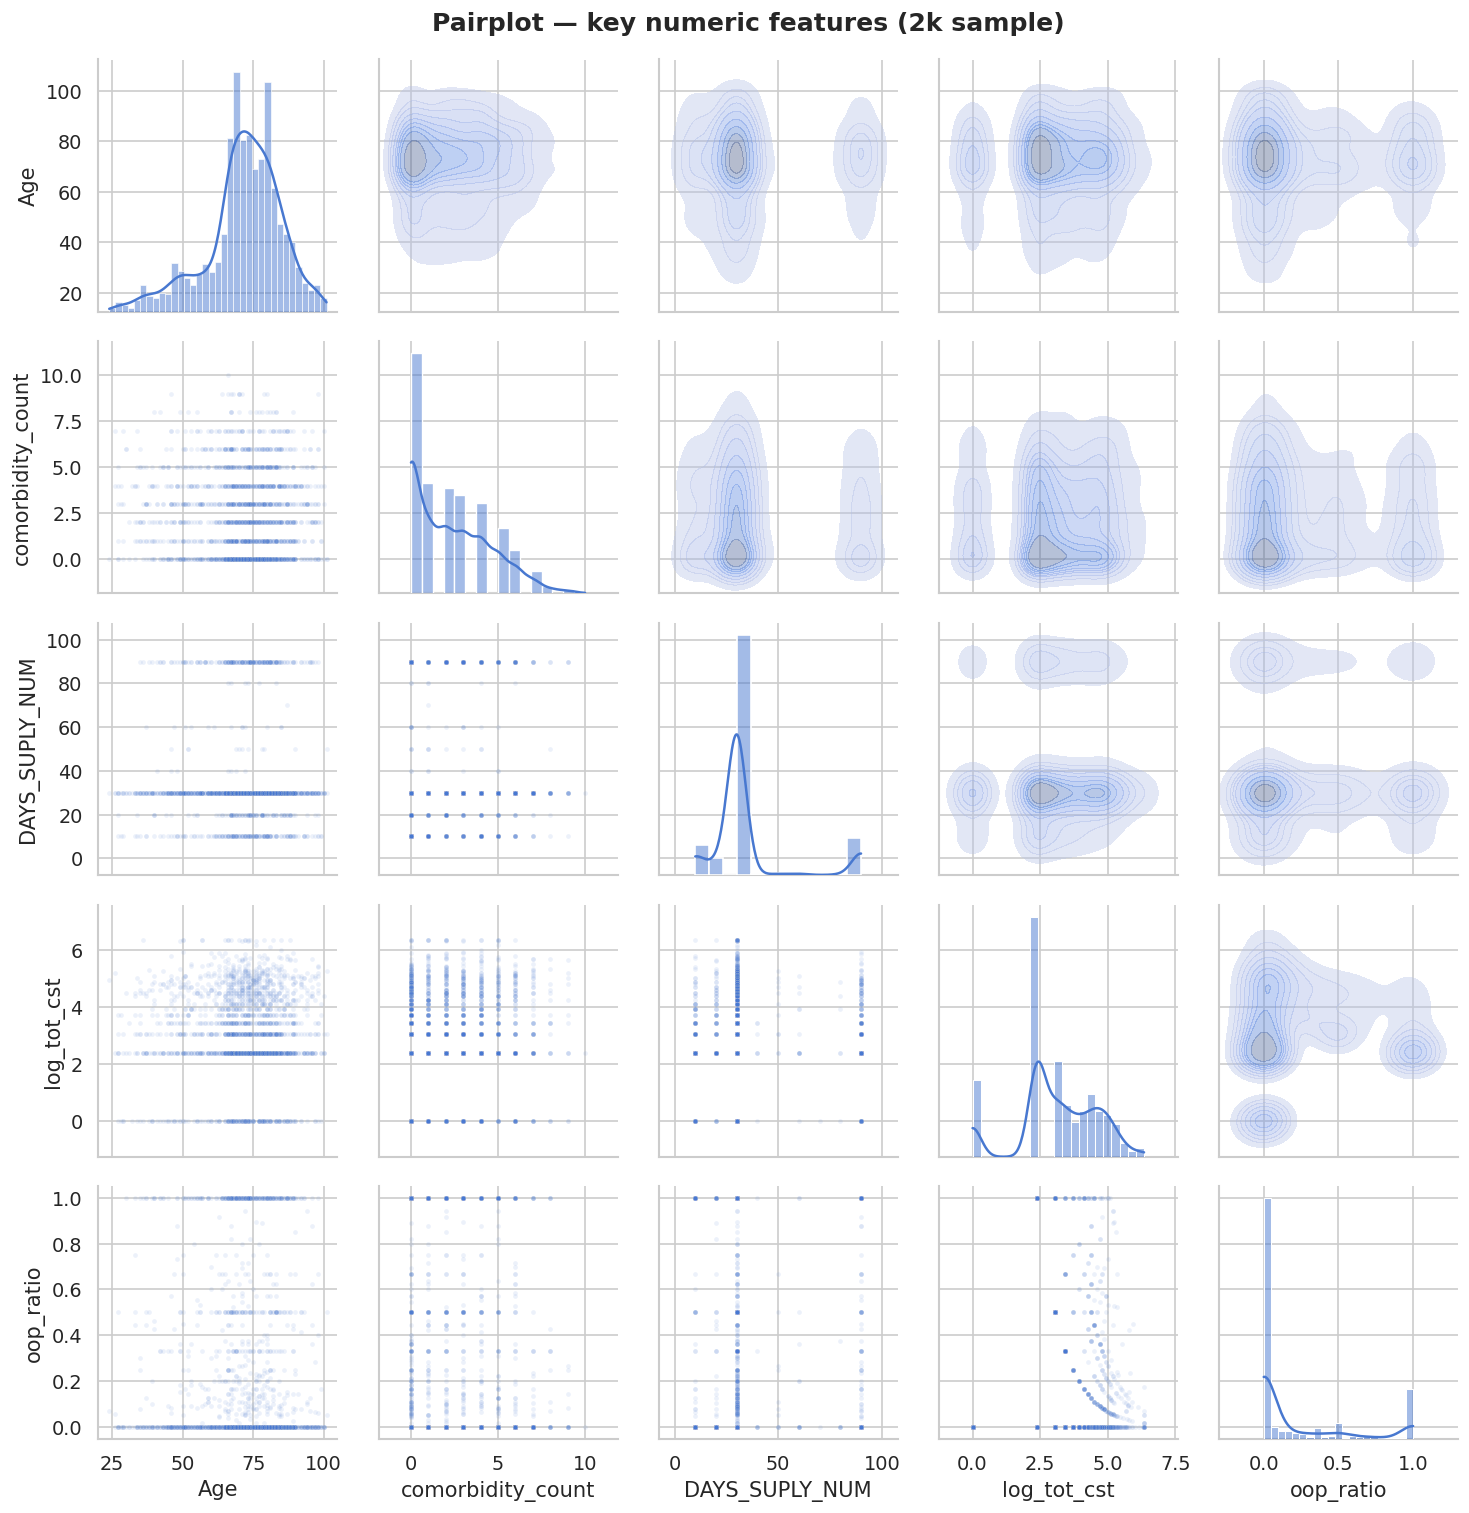

In [47]:
# ── Pairplot of key features (sampled for speed) ──────────────────────────────
pair_cols = ['Age','comorbidity_count','DAYS_SUPLY_NUM','log_tot_cst','oop_ratio']
pair_cols = [c for c in pair_cols if c in df.columns]
sample = df[pair_cols].dropna().sample(min(2000, len(df)), random_state=42)

g = sns.PairGrid(sample, diag_sharey=False)
g.map_diag(sns.histplot, kde=True, color=PALETTE[0])
g.map_lower(sns.scatterplot, alpha=0.1, s=8, color=PALETTE[0])
g.map_upper(sns.kdeplot, fill=True, alpha=0.4)
g.fig.suptitle('Pairplot — key numeric features (2k sample)', y=1.01, fontweight='bold')
plt.show()

---
## 11. EDA Summary

Printed summary of key counts and rates for quick reference. Use these figures when writing up methodology or checking results are consistent across notebooks.


In [30]:
print('='*55)
print('EDA SUMMARY')
print('='*55)
print(f'  Total claims          : {len(df):,}')
print(f'  Unique patients       : {df["DESYNPUF_ID"].nunique():,}')
print(f'  Unique ingredients    : {df["INGREDIENT"].nunique():,}')
print(f'  Date range            : {df["SRVC_DT"].min().date()} → {df["SRVC_DT"].max().date()}')
print(f'  Median age            : {pt_df["Age"].median():.0f} yrs')
print(f'  Median comorbidities  : {pt_df["comorbidity_count"].median():.0f}')
print(f'  Chronic fills (≥28d)  : {(df["DAYS_SUPLY_NUM"] >= 28).mean()*100:.1f}%')
print(f'  High financial barrier: {df["flag_high_financial_barrier"].mean()*100:.1f}%')
print()
print(f'  MISSES grouping key   : DESYNPUF_ID + INGREDIENT')
print(f'  Grace window          : {GRACE_DAYS} days')
print(f'  Labelled fills        : {len(labelled):,} ({len(labelled)/len(df)*100:.1f}% of total)')
print(f'  Late refill rate      : {late_rate:.1f}%')
print(f'  Chronic late patients : {chronic_pct:.1f}% (≥50% late fills)')
print('='*55)

EDA SUMMARY
  Total claims          : 5,373,237
  Unique patients       : 92,118
  Unique ingredients    : 10
  Date range            : 2008-01-01 → 2010-12-31
  Median age            : 72 yrs
  Median comorbidities  : 2
  Chronic fills (≥28d)  : 86.3%
  High financial barrier: 15.7%

  MISSES grouping key   : DESYNPUF_ID + INGREDIENT
  Grace window          : 14 days
  Labelled fills        : 4,795,824 (89.3% of total)
  Late refill rate      : 26.2%
  Chronic late patients : 29.5% (≥50% late fills)
